# README

Requirements
1) squirrel.csv
2) bunch of other libraries (sklearn, shap, xgboost, statsmodels, etc) which probably are already installed
3) press run

RQ1
1) Basic data cleaning and feature extraction
2) Added missing flags instead of remove/impute to find patterns in missingness
3) Spatial-related plots and relationship plots (corr, MI, etc)

RQ2
1) K-means clustering and KNN smoothing to create new features from spatial data
2) Label, target and frequency encoding for categorical variables (amongst other stuff)
4) Base models: Logistic Regression, Random Forest and XGBoost (TARGET="SHIFT")
3) Pass 1: Use K-folds CV to get mean SHAP values and permutation importances across folds, then select the top k features based on equally-weighted ranks
4) Pass 2: Use CV again to get OOF predictions and test predictions using top k features
5) Majority voting which equally weights all test predictions to produce the final predictions
6) Meta-model (LR): Learns relationships between the base models' OOF predictions and "SHIFT", then uses test predictions to produce the final predictions, achieving 96% ROC-AUC (+26% vs baseline RF w/o feat. eng. (from previous iteration of code))

Plots
1) Spatial-plots to see dominant behaviour distribution across hectares/clusters  
2) Correlation of behaviours with change in coordinates (X, Y, HectareSN, HectareWE)
3) Mutual information between spatial-related labels and behaviours
4) Heatmap to see mean behaviour across clusters (pseudo probability)




In [611]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
#import lightgbm as lgb
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import shap
from sklearn.model_selection import learning_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from tqdm import tqdm
import statsmodels.api as sm
from sklearn.inspection import permutation_importance

# Data Cleaning

In [612]:
#Loading Data
df = pd.read_csv("squirrel.csv")
df.drop(columns=["Unique Squirrel ID", "Color notes", "Specific Location", "Lat/Long", "Combination of Primary and Highlight Color"], inplace=True)
#Unique Squirrel ID, Lat/Long and Combination of Primary and Highlight Color are redundant,
#"Color notes", "Specific Location" has too many nulls
#obviously could still be used, but probably not worth the effort to parse

#Standardise Data
df["Age"] = df["Age"].replace('?', np.nan) #assumes ? means nan
df["Date"] = pd.to_datetime(df['Date'].astype(str), format='%m%d%Y')
df['Day'] = df["Date"].dt.day
df['Above Ground Sighter Measurement'] = df['Above Ground Sighter Measurement'].replace('FALSE', '0').astype("float64") #assumes False means 0

#Additional Features
df["HectareSN"] = df['Hectare'].str[:2].astype(int)
df["HectareWE"] = df['Hectare'].str[2:].apply(lambda x: ord(x.lower()) - 96)
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['is_weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

df['OA_Desc_Length'] = df['Other Activities'].str.split().str.len().fillna(0)
df['OA_Interaction_Count'] = df['Other Activities'].str.findall(r'#(\d+)').apply(lambda x: len(set(x)) if isinstance(x, list) else 0) #unique interactions
df['OI_Desc_Length'] = df['Other Activities'].str.split().str.len().fillna(0)
#could optionally further parse Other Activities and Other Interactions
#example: most common n-grams (1, 2) as new cols (dog, tree, etc)
#example: if Running is currently 0, but mentioned to be running/ran/run, then adjust to 1
#example: parse r'#(\d{1,2})' to count number of unique interactions with other squirrels (set)
#did not include the above as contribution is probably negligable
df.drop(columns=["Date", "Other Activities", "Other Interactions"], inplace=True)
#print(df.info())

#Purpose: Standardise, improve data readability for eda and ml, remove iinconsistentency, remove redudant info
#Purpose: Extract usefull info from raw data, detect patterns more easily

In [613]:
#Target
TARGET = "Shift"

#Missing Data (adds missing flags to find signals in missingness and prevent imputation bias)
obj_cols = df.select_dtypes(include=['object']).columns.tolist()
if TARGET in obj_cols: obj_cols.remove(TARGET)
for col in obj_cols:
    df[col] = df[col].astype(str).str.strip().replace('', np.nan)
df[obj_cols] = df[obj_cols].fillna('nan')

num_cols = df.select_dtypes(include=['number']).columns.tolist()
if TARGET in num_cols: num_cols.remove(TARGET)
for col in num_cols:
    df[f'{col}_is_missing'] = df[col].isna().astype(int)
    df[col] = df[col].fillna(df[col].median()) #could use model-based impute instead

bool_cols = df.select_dtypes(include=['bool']).columns.tolist()
if TARGET in bool_cols: bool_cols.remove(TARGET)
for col in bool_cols:
    df[f'{col}_is_missing'] = df[col].isna().astype(int)
    df[col] = df[col].astype(float).fillna(0)
#assumes nan means 0

#Encoding (used label encoding despite implying false order as it is better for tree-based models and just simpler)
obj_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in obj_cols:
    df[col] = df[col].astype('category').cat.codes #label encode
ohe_cols = [col for col in obj_cols if col != TARGET] #hidden leakage if includes OHE target as a feature :)
ohe = pd.get_dummies(
    df[ohe_cols].astype('object'),
    prefix=ohe_cols,
    drop_first=True #prevent perfect multicollinearity: singur/non-invertible/det(X)=0, for LR
).astype("float64")
df = pd.concat([df, ohe], axis=1)
#one-hot enoding may lead to feature fragmentation and larger dimensions(from high cardinality features), worse for DT (slower), but better for LR
#decided to do both and let feature selection part figure it out

#Features
behaviour_cols = bool_cols + ["Age", "Location"] + ["Shift"] + ["is_weekend"]
day_cols = ["Day", "DayOfWeek"]
coords = ["X", "Y"]
ohe_cols = ohe.columns.tolist()
le_cols = obj_cols

#Purpose: ensure dataset is complete
#Purpose: allow models to process non-numerical information

# 1. Does a squirrel's location within Central Park influence its behavioural patterns, and can we identify distinct spatial zones in the park that correspond to specific behaviours such as foraging, running, or eating?



Spatial Plots

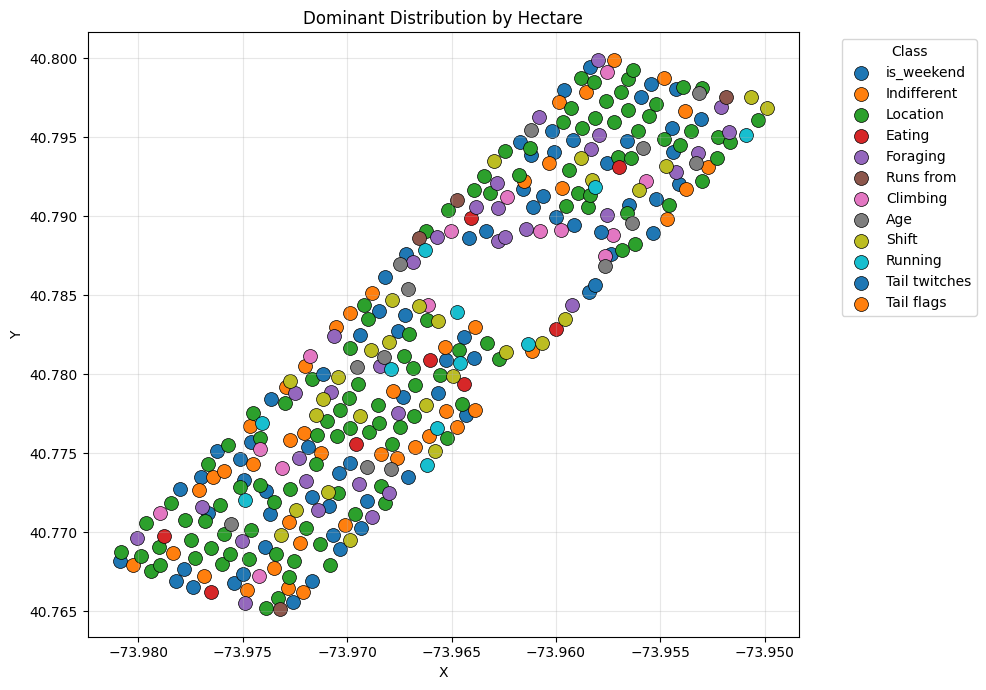

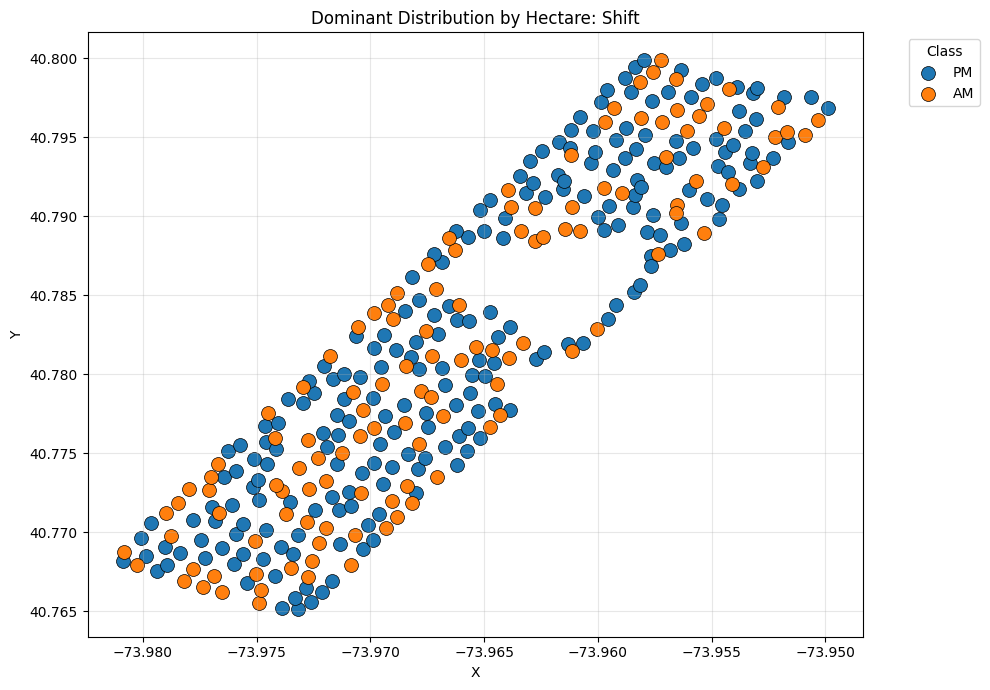

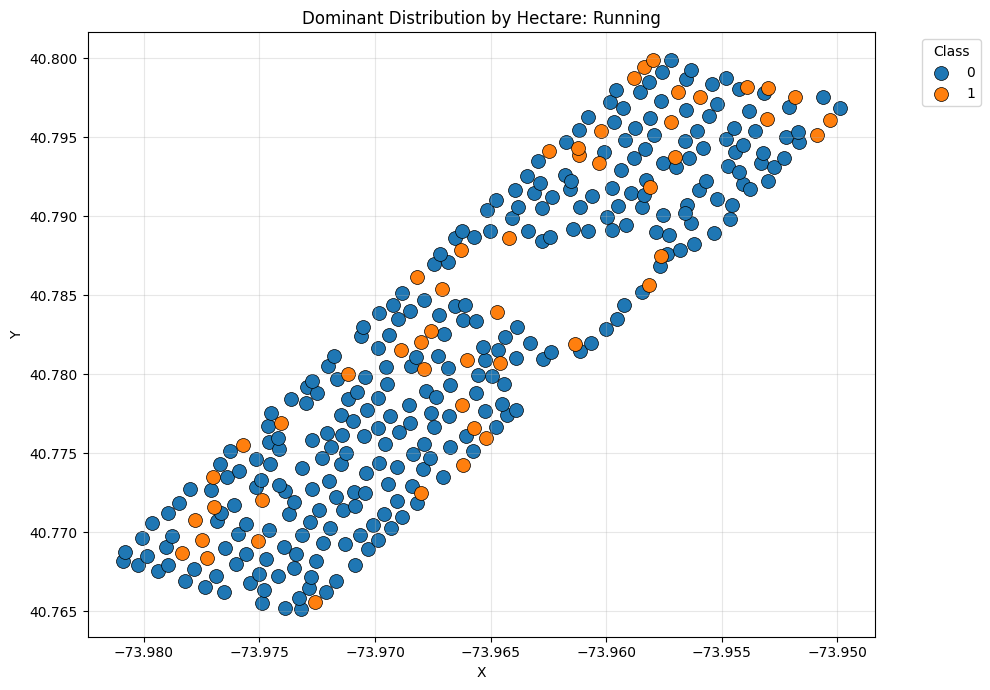

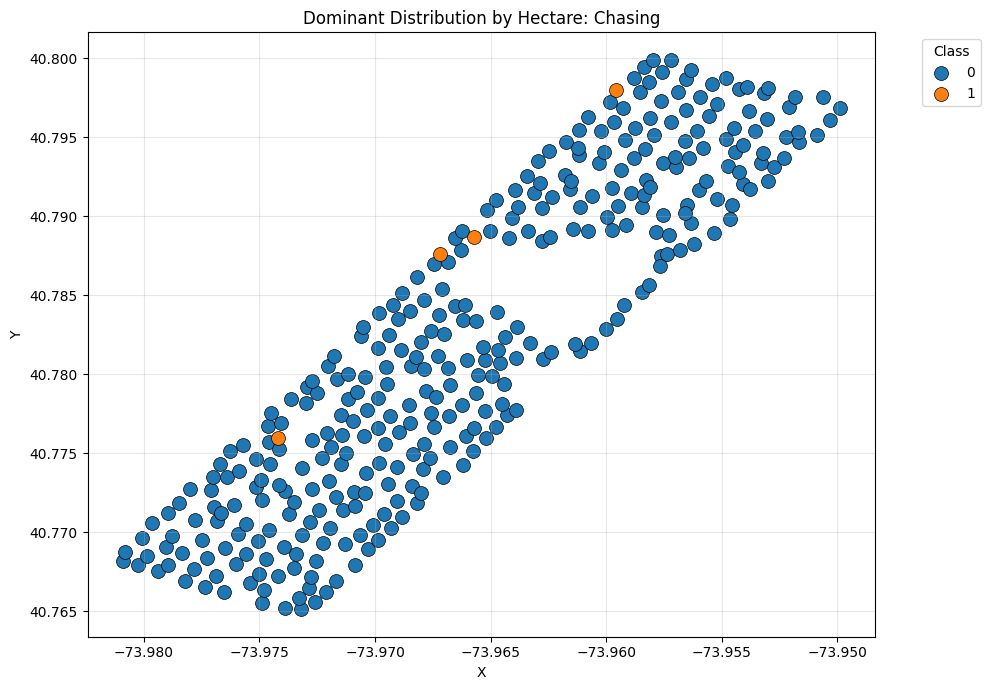

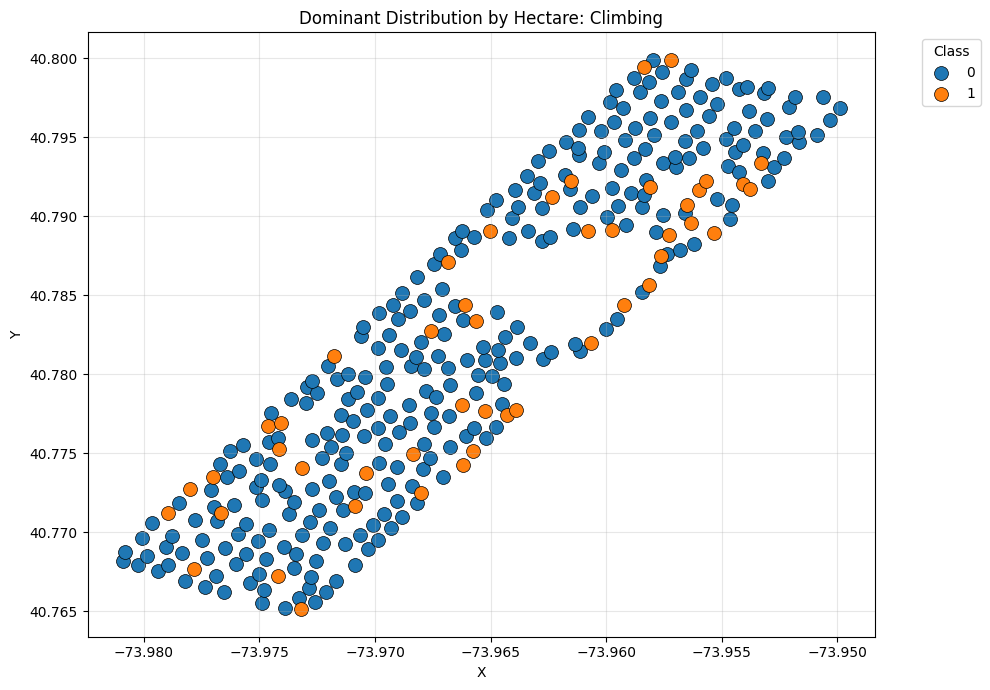

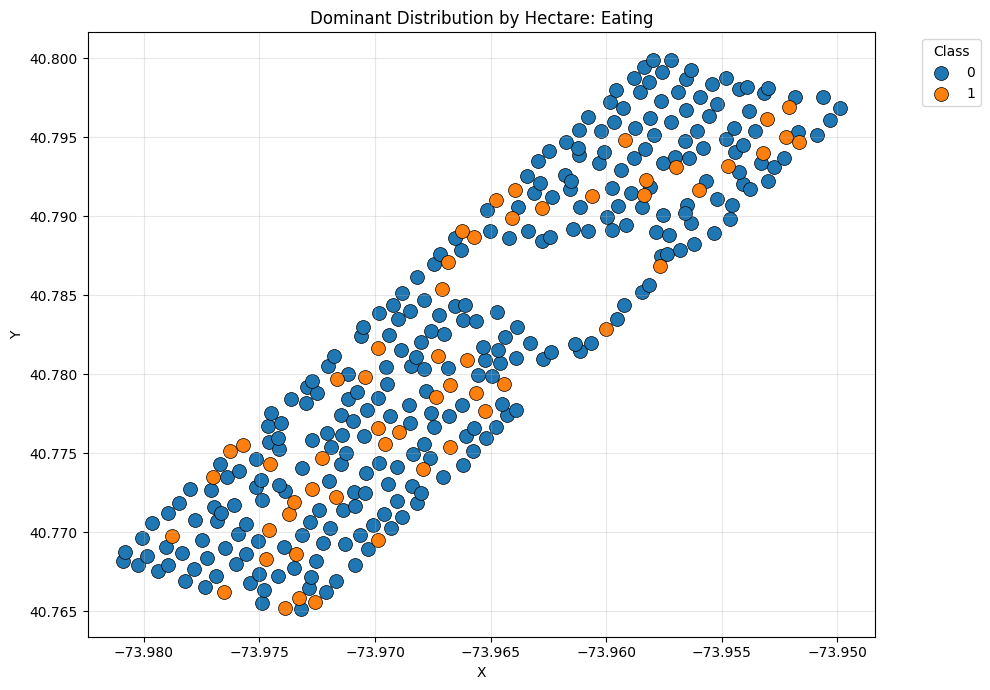

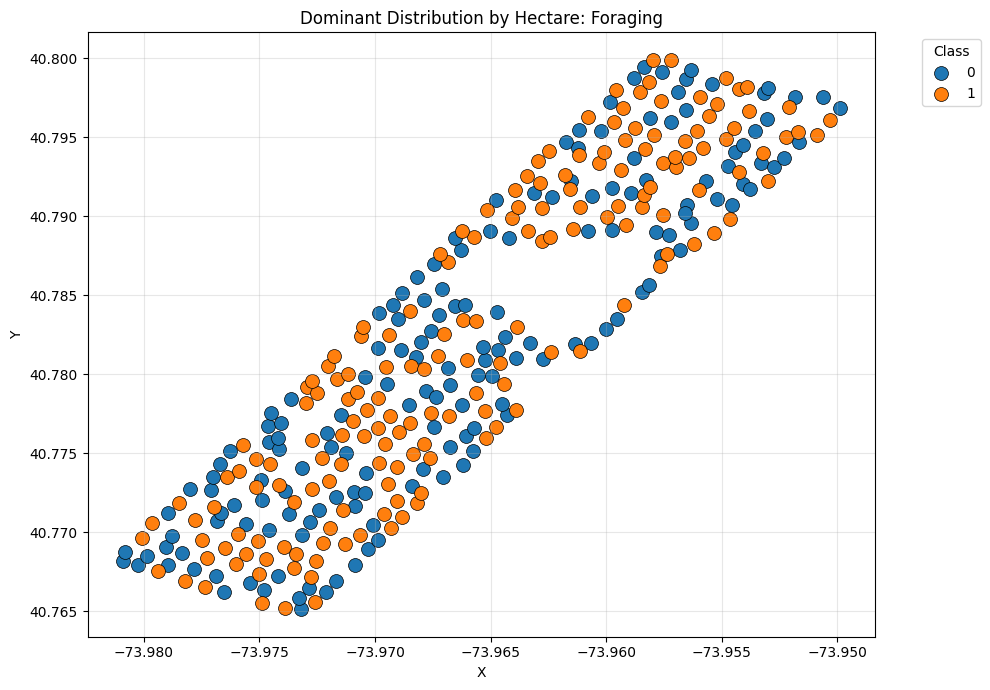

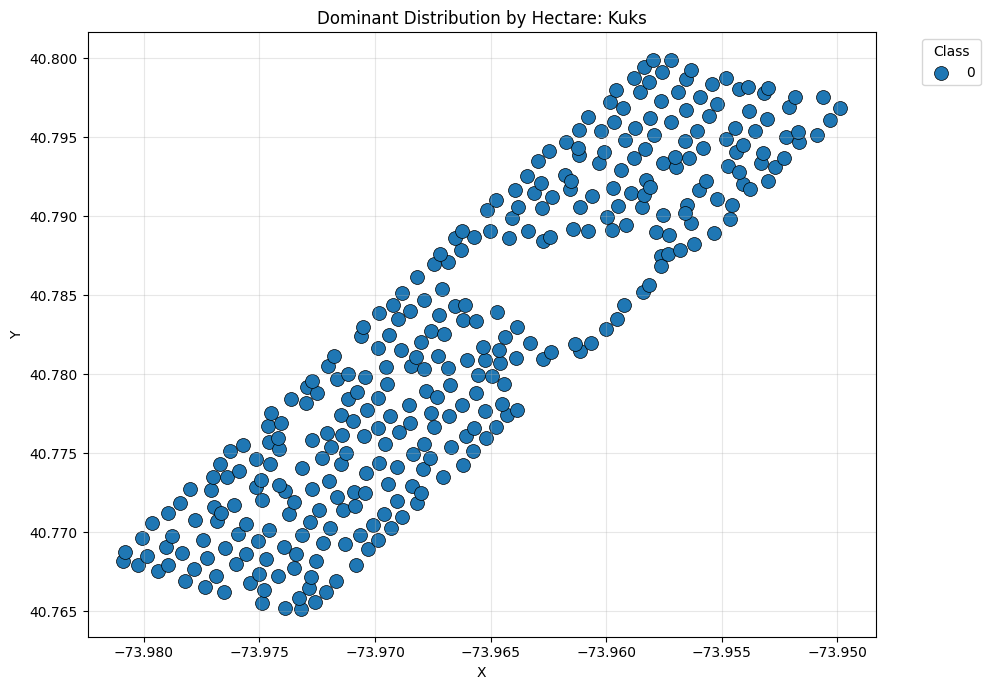

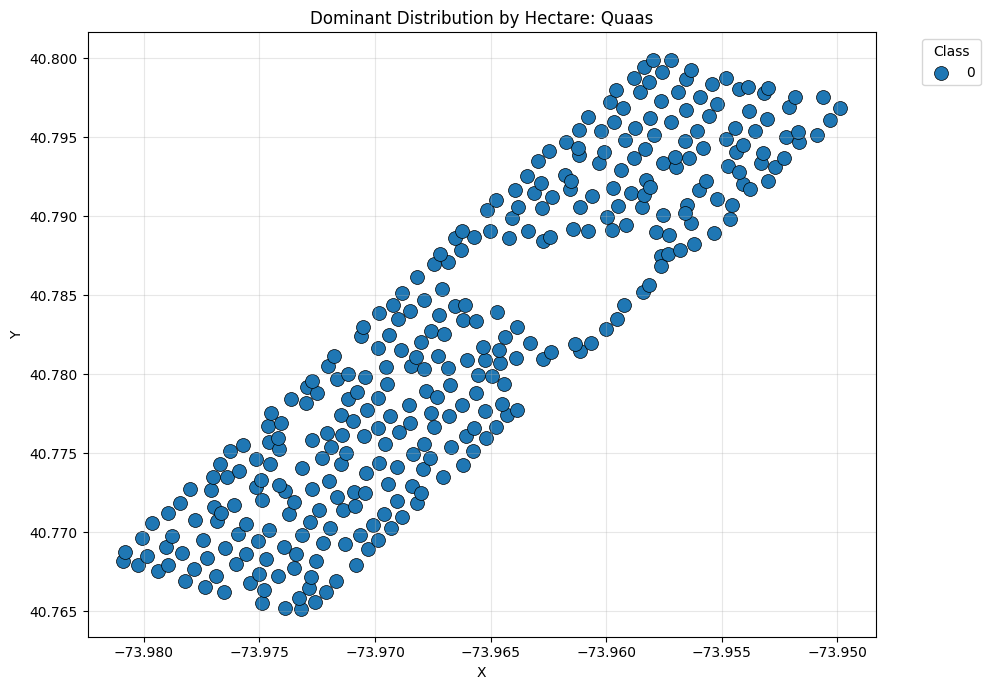

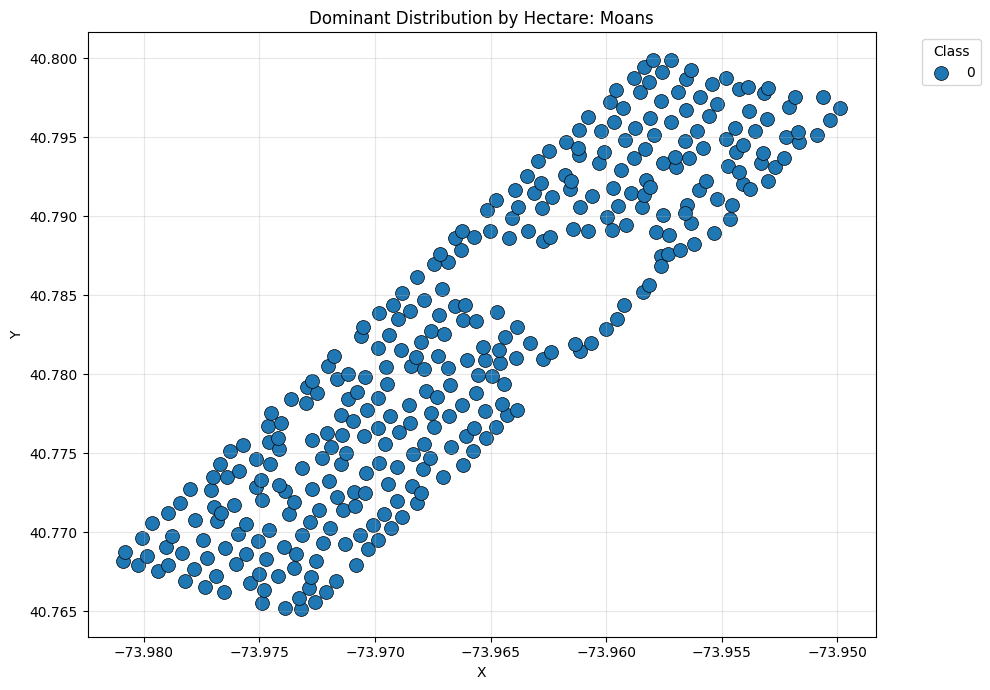

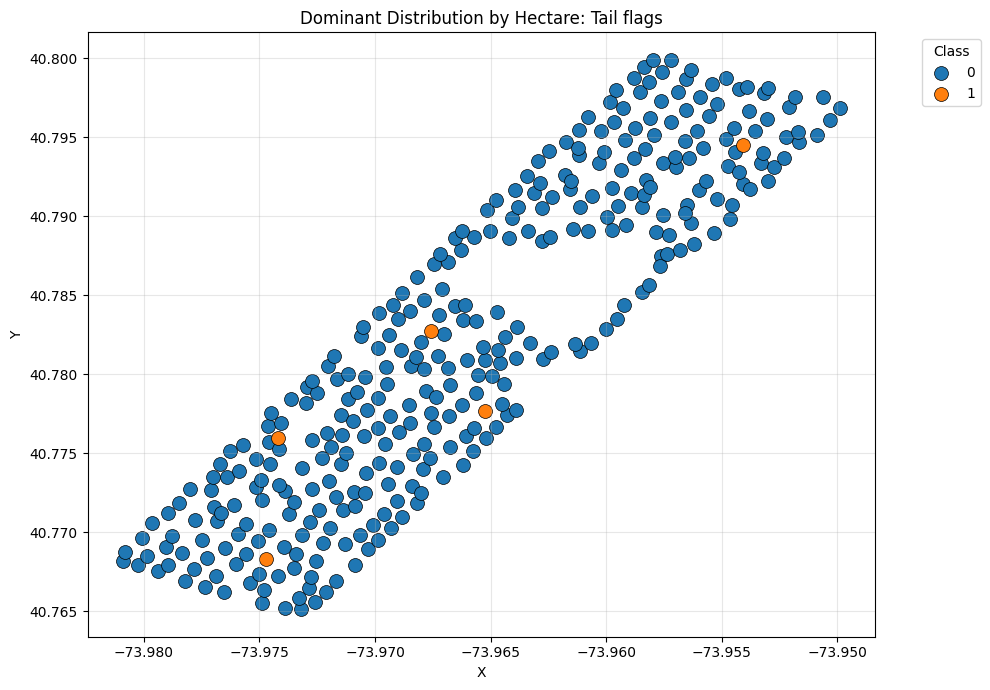

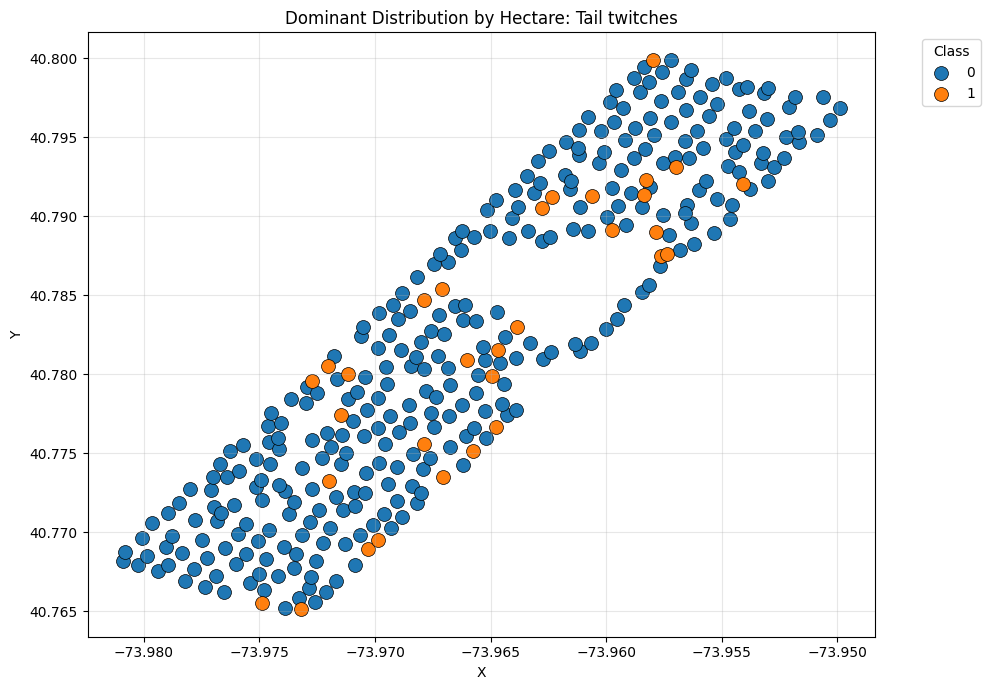

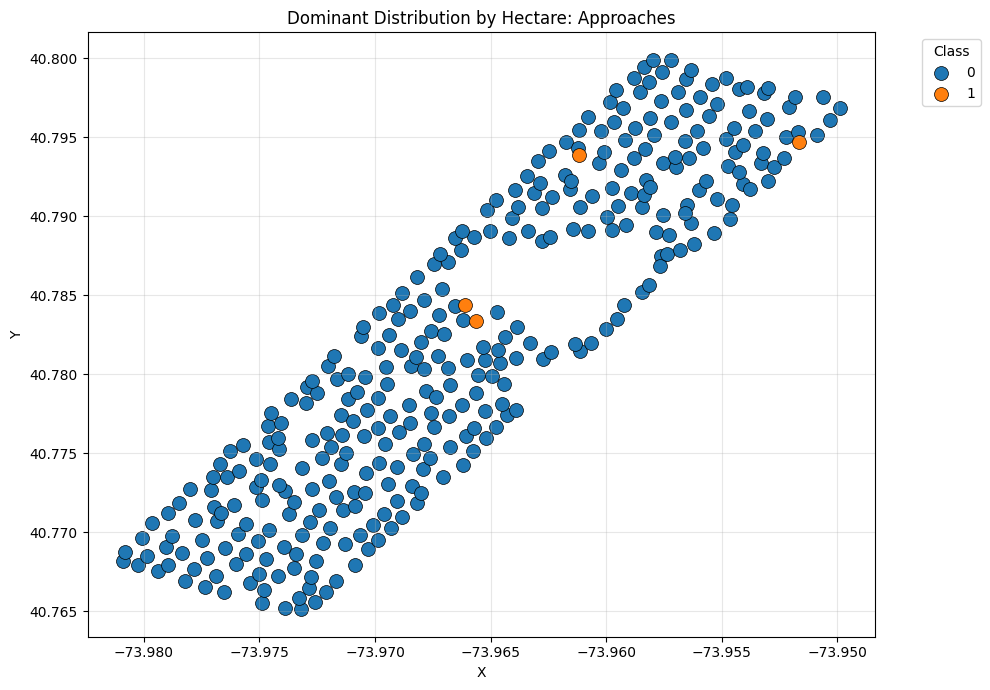

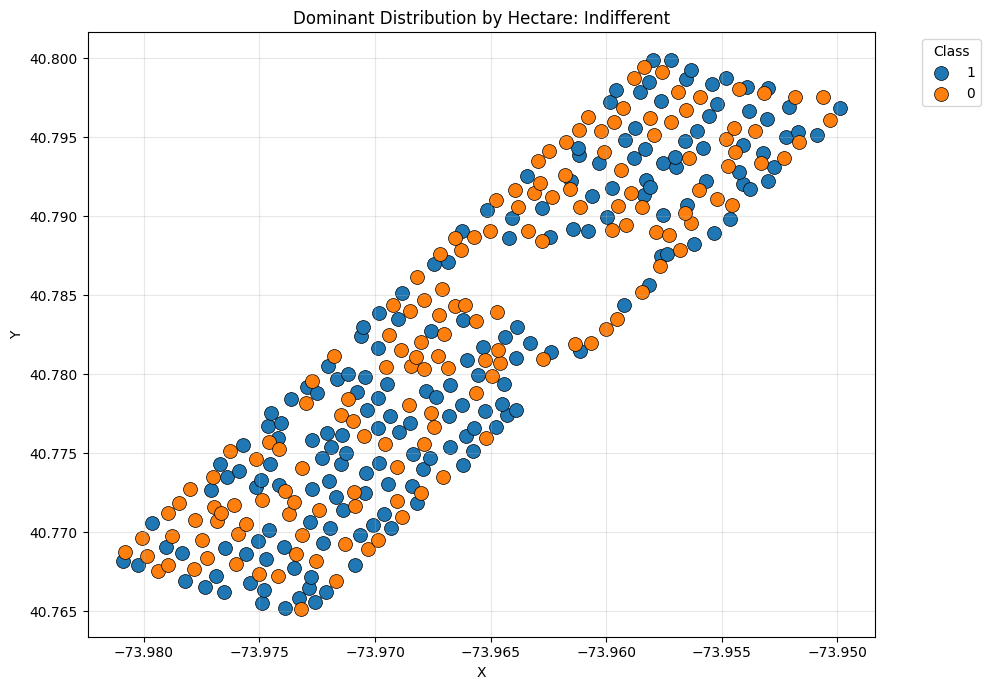

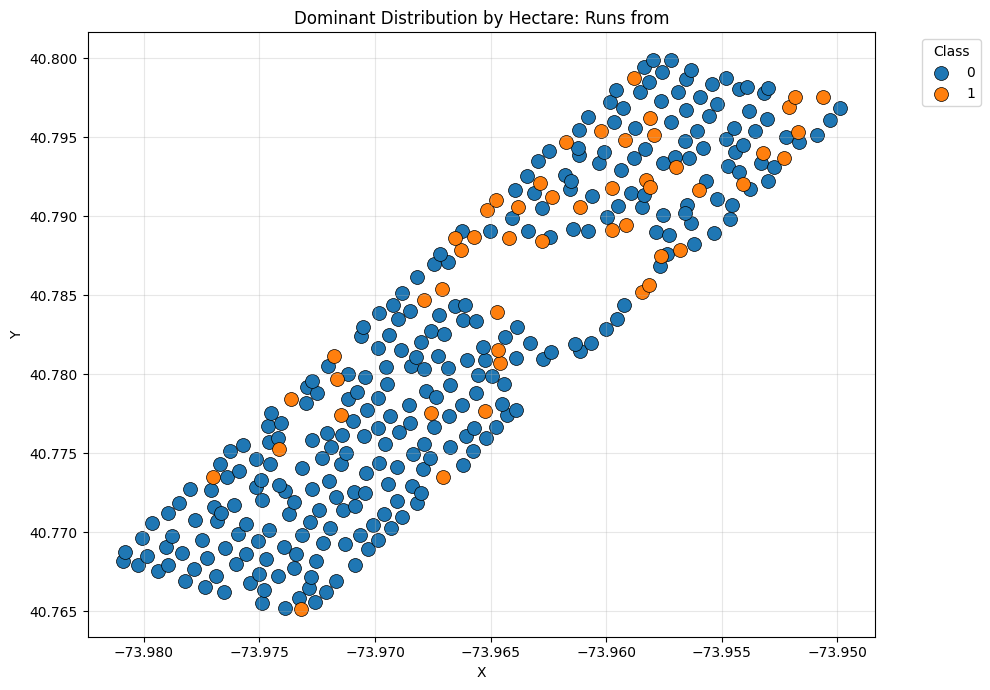

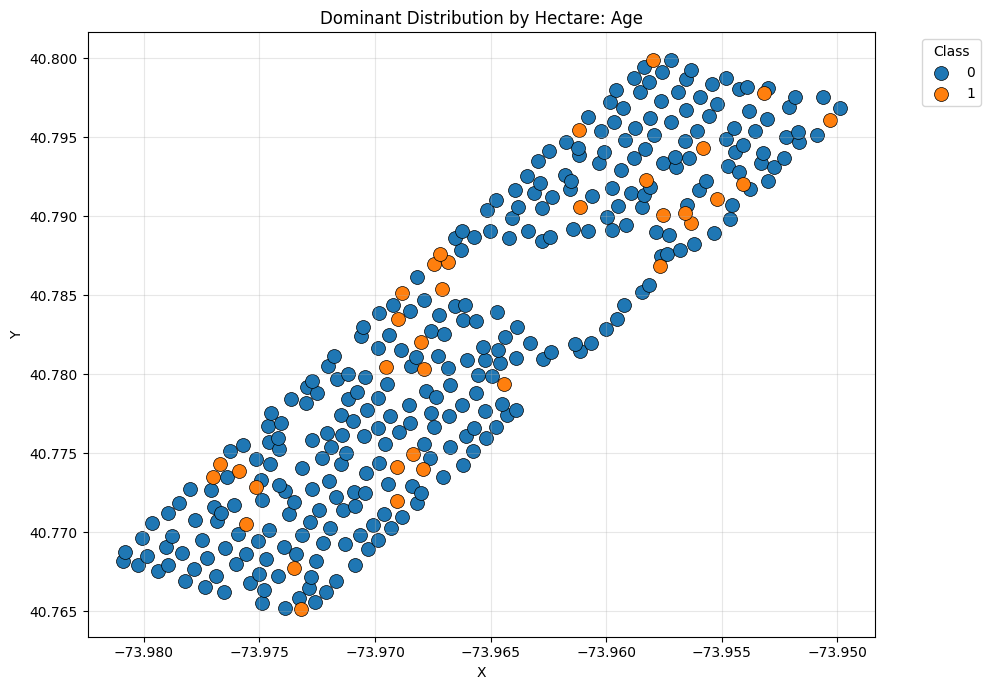

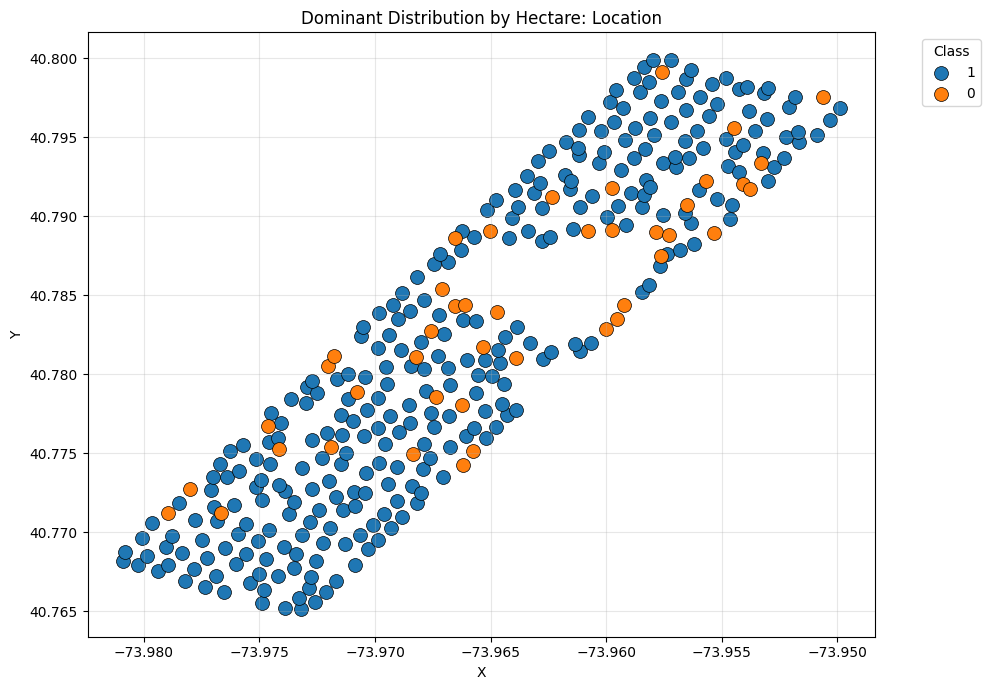

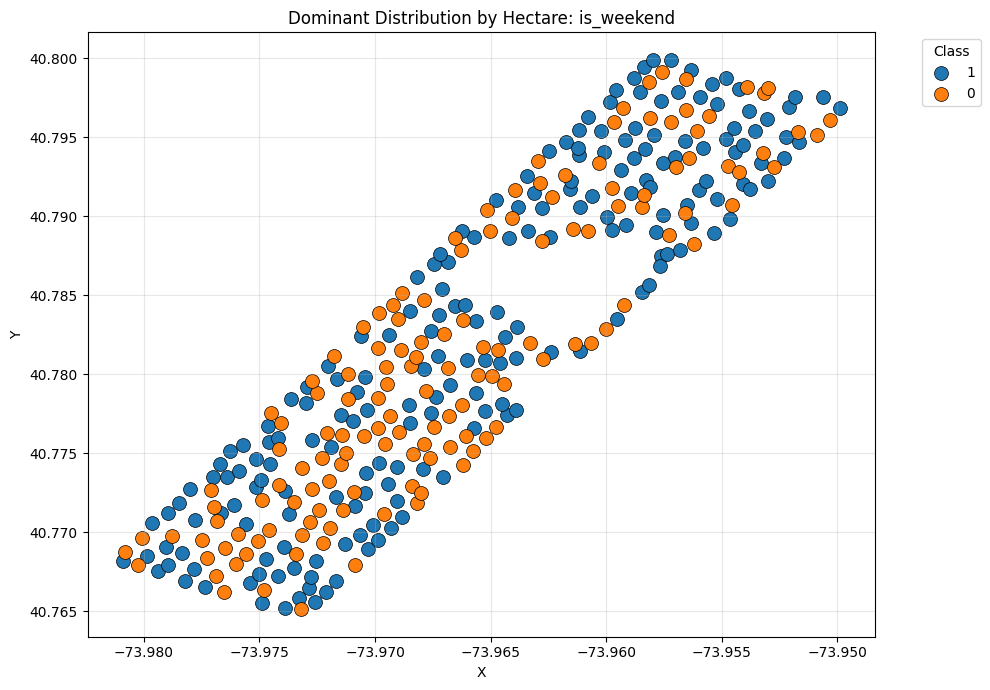

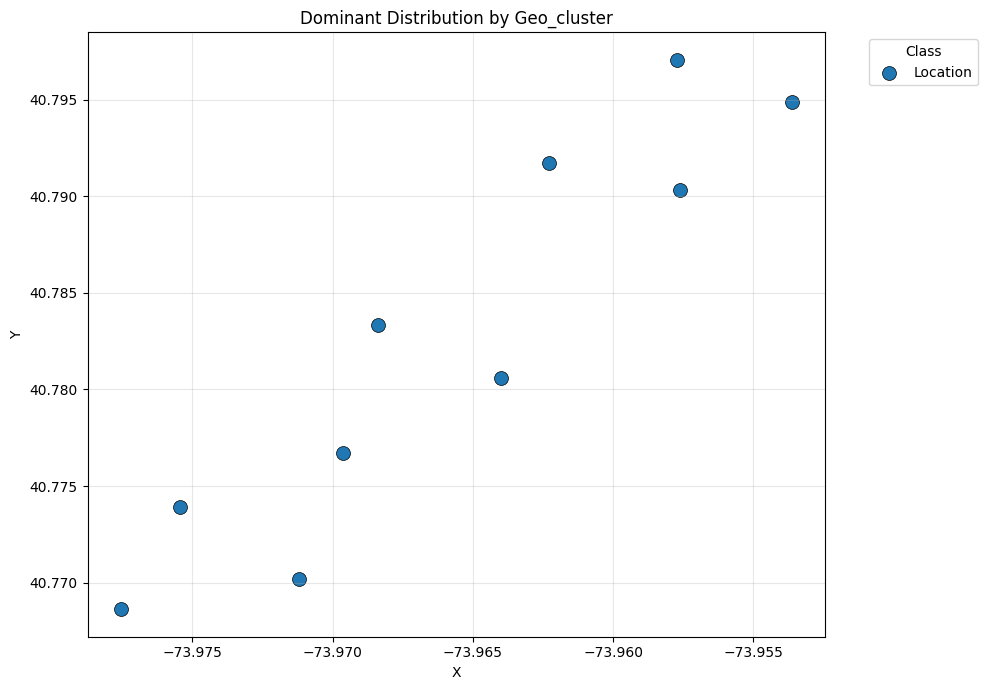

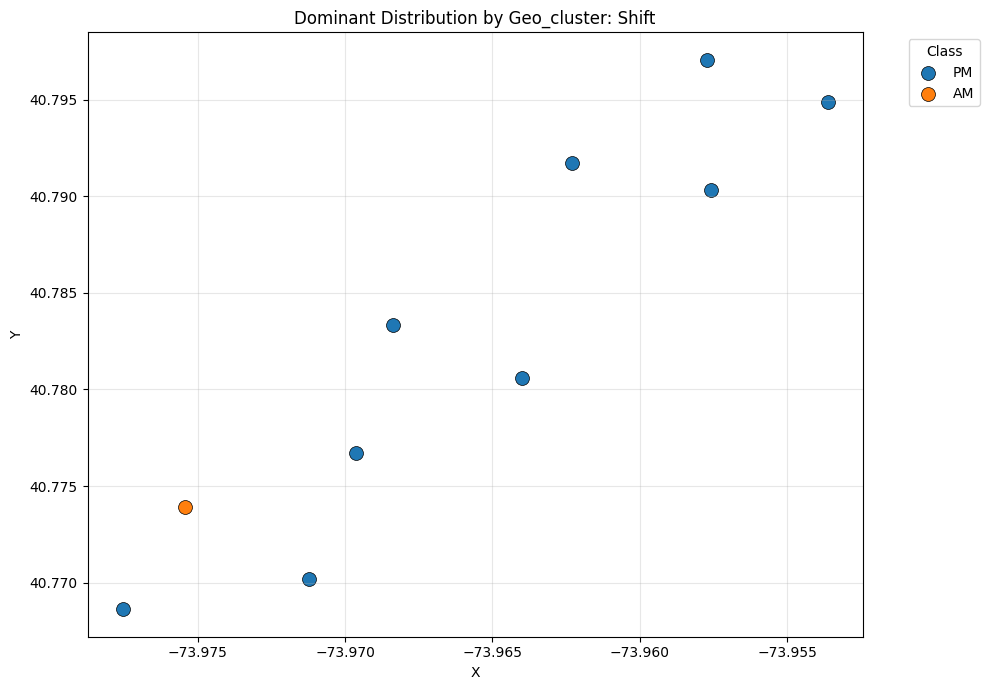

In [614]:
def location_plot(df, hue_col):
    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=df, x='X', y='Y', hue=hue_col, palette='tab20', s=20, alpha=0.6)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title(f"Location ({hue_col})")
    plt.tight_layout()
    plt.show()

def plot_spatial_grid(df, behavioural_cols, lat_col="X", lon_col="Y", group_col="Hectare", labels=["0", "1"]):
    if isinstance(behavioural_cols, str):
        temp_df = df.copy()
        temp_df[labels[1]] = (temp_df[behavioural_cols] > 0.5).astype(int)
        temp_df[labels[0]] = (temp_df[behavioural_cols] <= 0.5).astype(int)
        active_cols = [labels[1], labels[0]]
        title_suffix = f": {behavioural_cols}"
    else:
        temp_df = df
        active_cols = behavioural_cols
        title_suffix = ""

    plot_cols = active_cols + [lat_col, lon_col]
    data = temp_df.groupby(group_col)[plot_cols].mean()
    data["dominant"] = data[active_cols].idxmax(axis=1)

    plt.figure(figsize=(10, 7))
    for label in data["dominant"].unique():
        mask = data["dominant"] == label
        plt.scatter(data.loc[mask, lat_col], data.loc[mask, lon_col], label=label, s=100, edgecolor='black', linewidth=0.5)

    plt.title(f"Dominant Distribution by {group_col}{title_suffix}")
    plt.xlabel(lat_col)
    plt.ylabel(lon_col)
    plt.legend(title="Class", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def new_cluster(df, input_cols, target_col, name, n=10, ADD=True):
    temp_df = df.copy()
    cluster_col = f'{name}_cluster'
    stat_col = f'{name}_cluster_{target_col}_mean'

    km = KMeans(n_clusters=n, n_init=10, random_state=42)
    cluster_labels = km.fit_predict(temp_df[input_cols])

    temp_df[cluster_col] = cluster_labels
    temp_df[stat_col] = temp_df.groupby(cluster_col)[target_col].transform('mean')

    if ADD:
        dist_matrix = km.transform(temp_df[input_cols])
        temp_df[f'{name}_dist_to_center'] = dist_matrix[np.arange(len(dist_matrix)), cluster_labels]
        temp_df[f'{name}_cluster_density'] = temp_df[cluster_col].map(temp_df[cluster_col].value_counts())
    return temp_df


train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

plot_spatial_grid(df, behaviour_cols, group_col="Hectare")
plot_spatial_grid(df, "Shift", group_col="Hectare", labels=["AM", "PM"])

for col in behaviour_cols:
  if col == "Shift": continue
  plot_spatial_grid(df, col, group_col="Hectare")

df = new_cluster(df, coords, TARGET, "Geo")
plot_spatial_grid(df, behaviour_cols, group_col="Geo_cluster")
plot_spatial_grid(df, "Shift", group_col="Geo_cluster", labels=["AM", "PM"])

#Purpose: cluster to capture spatial structure, hidden spatial patterns, new spatial feature
#also used for feat. eng., but with different implementation: OOF (train) and OOS (test) to prevent data leakage


Relationship Exploration

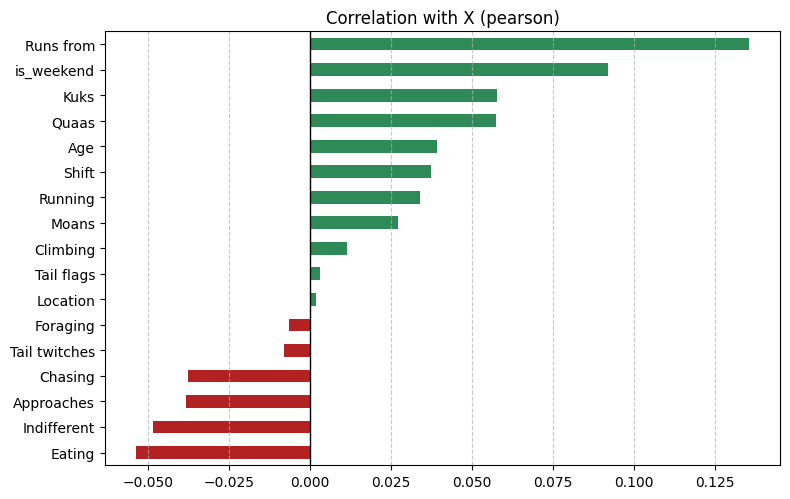

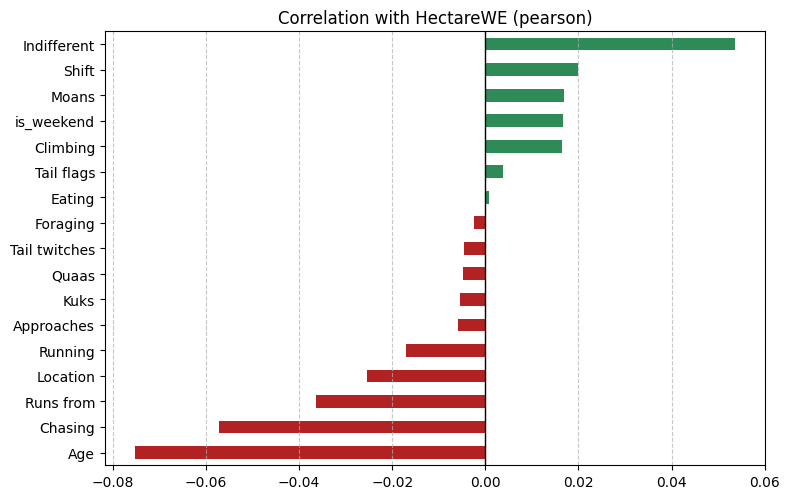

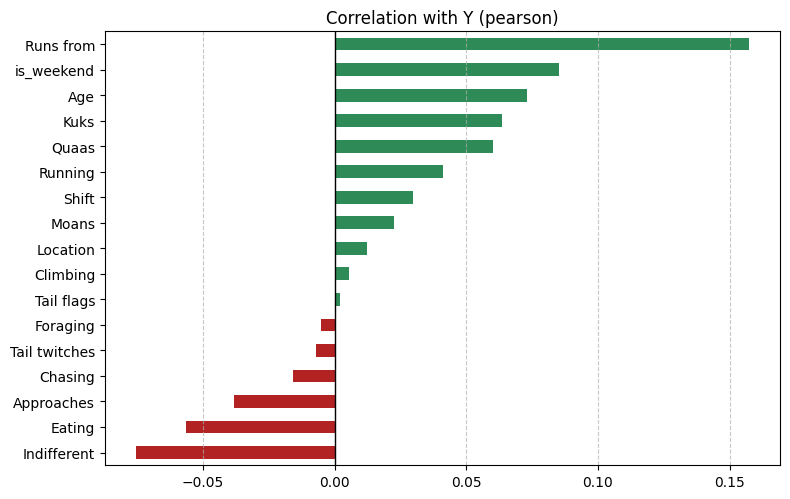

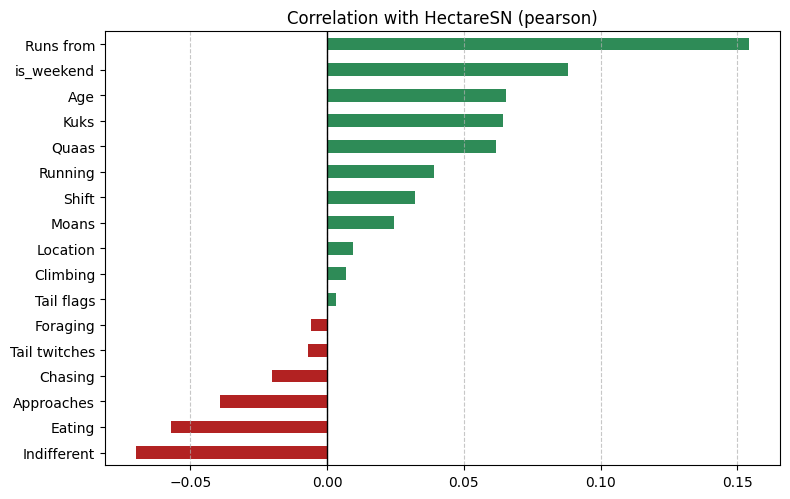

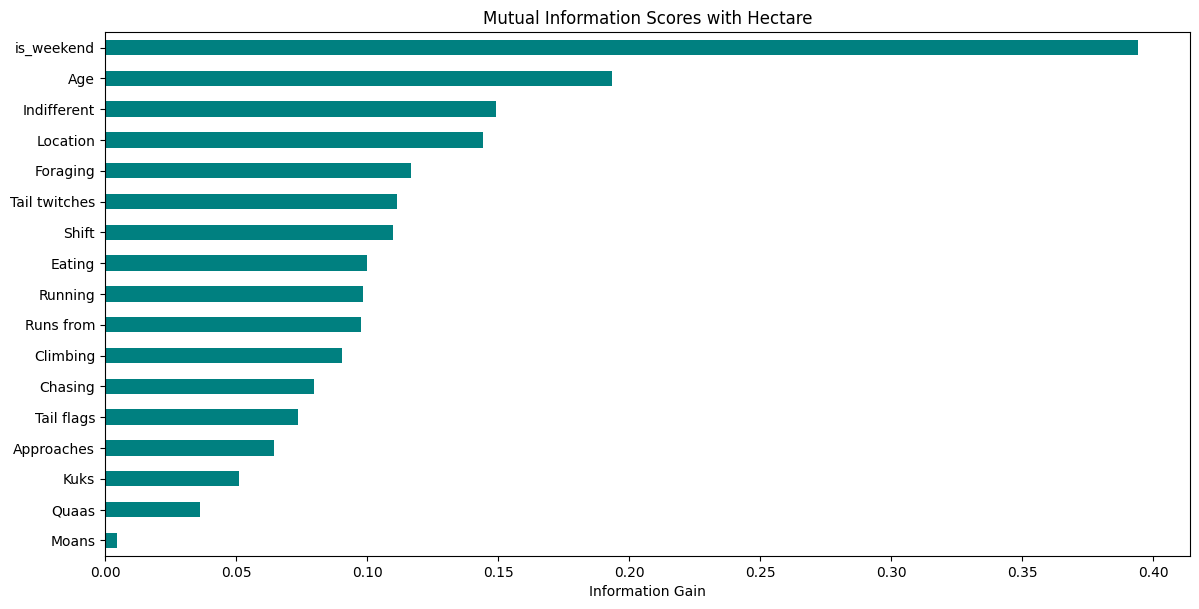

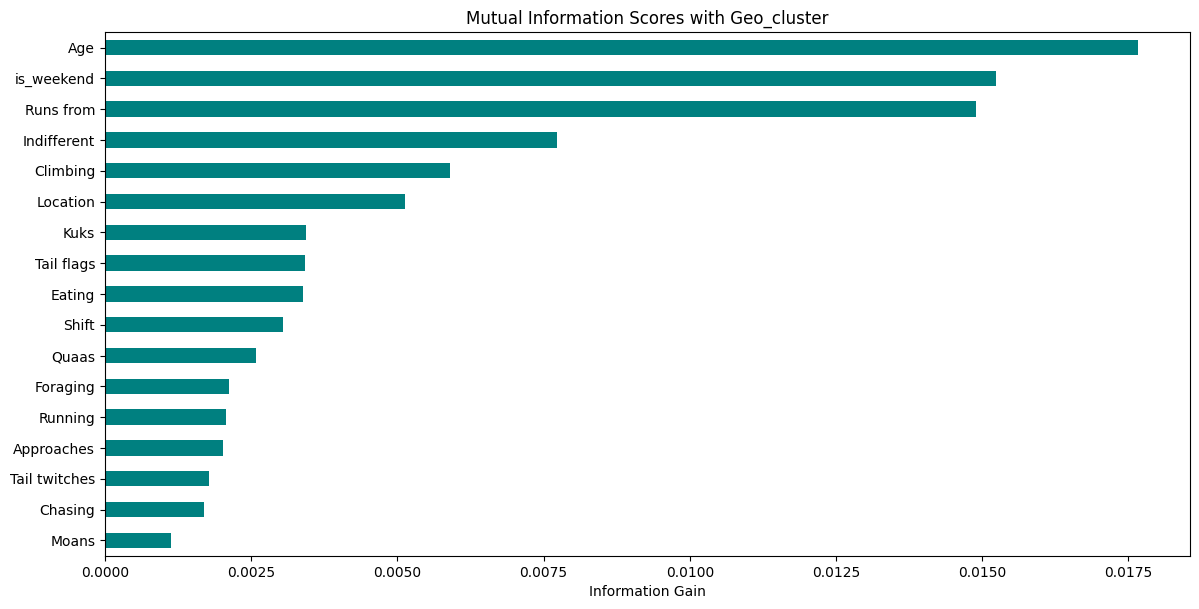

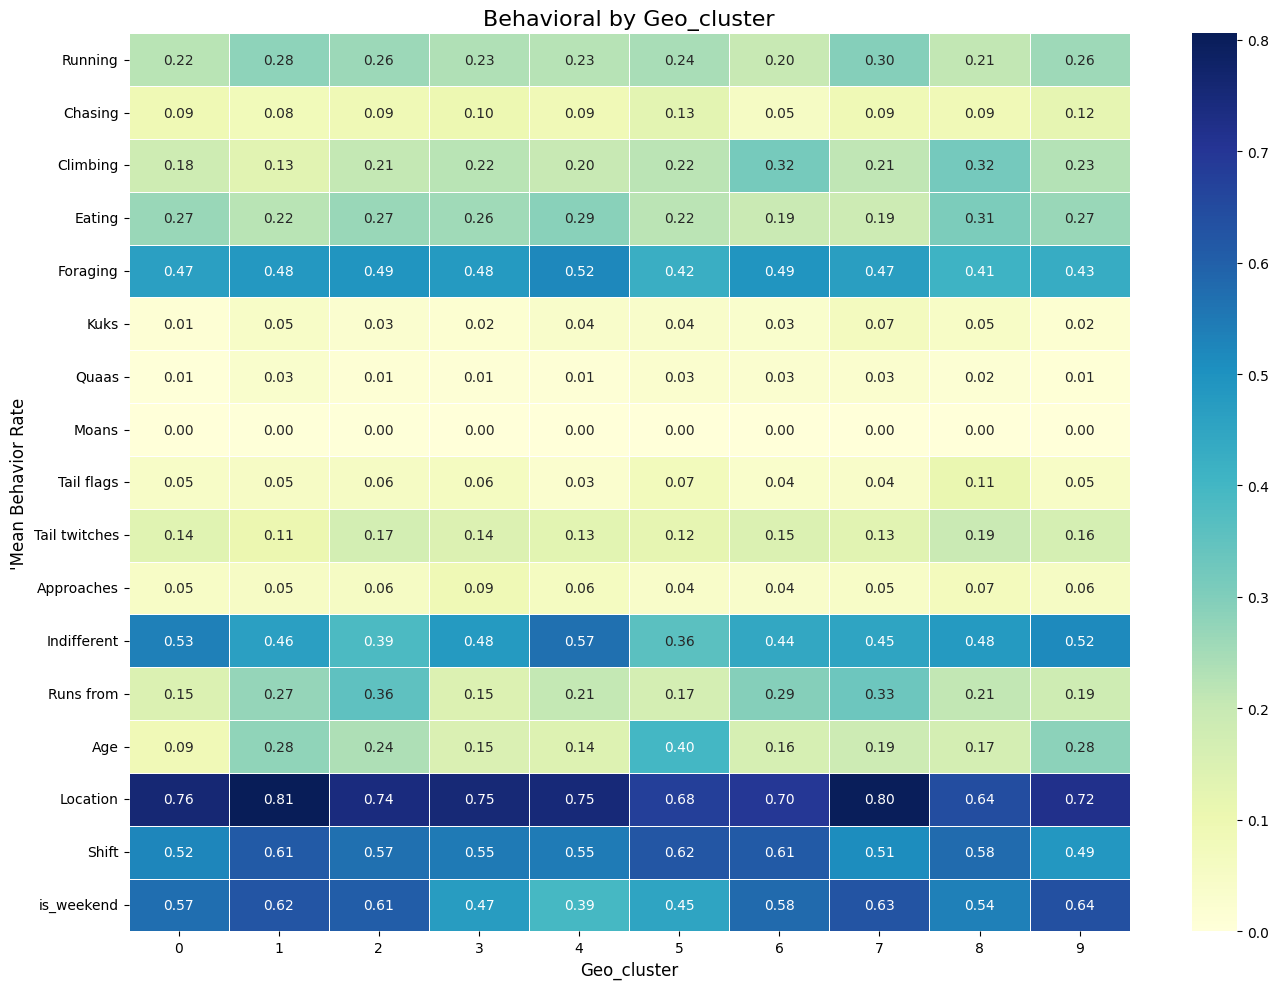

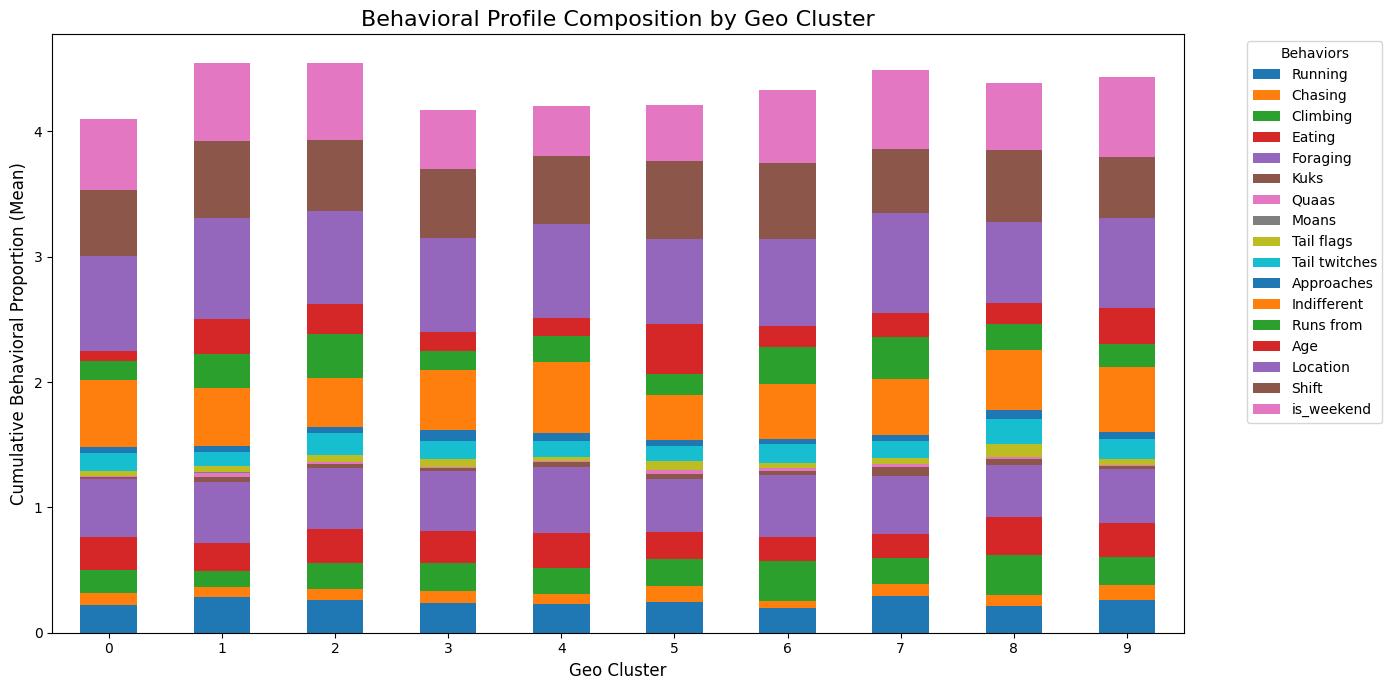

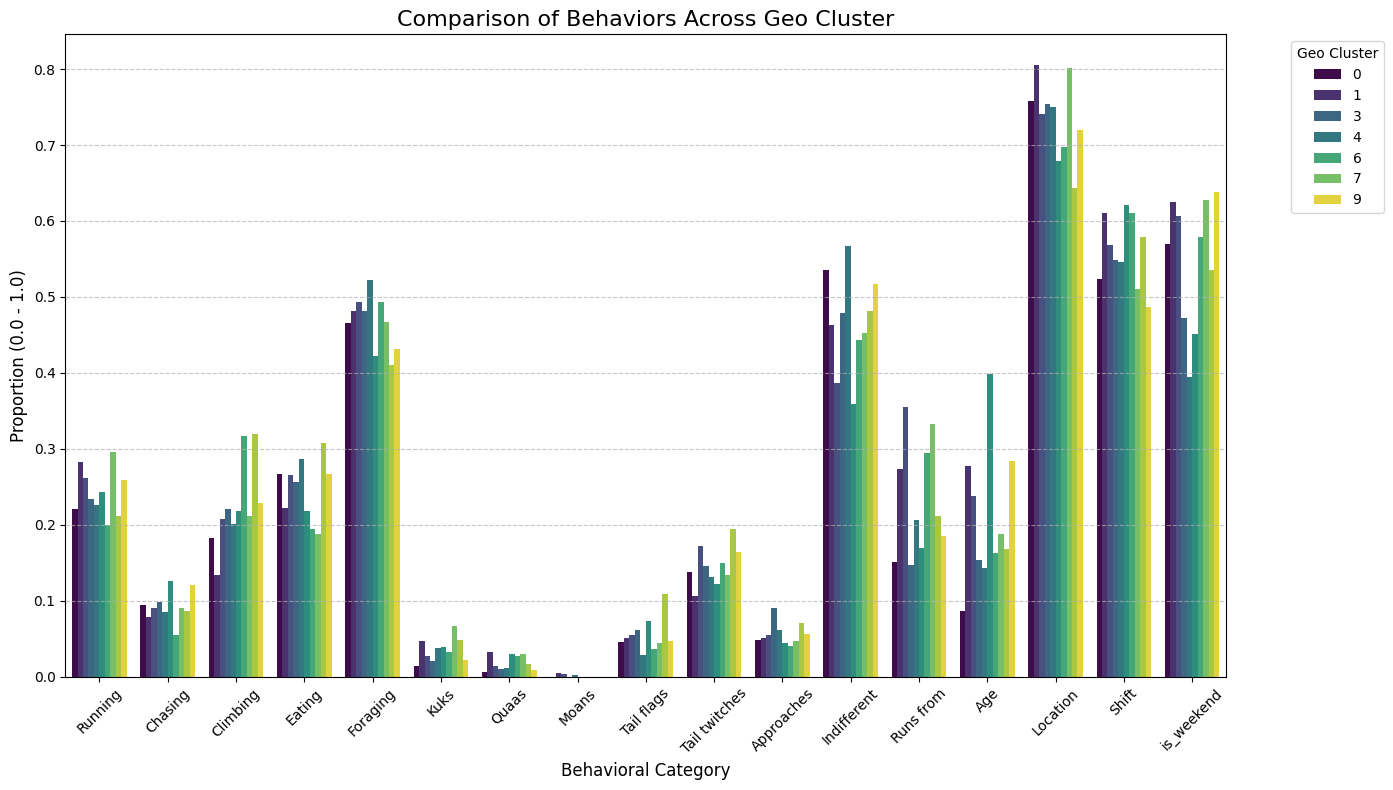

In [615]:
def plot_correlation(df, columns, method='pearson'):
    corr_matrix = df[columns].corr(method=method)

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title(f"Correlation Matrix ({method.capitalize()})")
    plt.show()

def plot_target_corr(df, features, target, method='pearson'):
    corr_matrix = df[features + [target]].corr(method=method)
    corrs = corr_matrix.loc[features, target]
    corrs = corrs.sort_values()

    plt.figure(figsize=(8, len(features) * 0.3))
    colors = ['firebrick' if x < 0 else 'seagreen' for x in corrs]
    corrs.plot(kind='barh', color=colors)
    plt.axvline(0, color='black', lw=1)
    plt.title(f"Correlation with {target} ({method})")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def plot_mutual_information(df, features, target):
    temp_df = df.copy()
    X = temp_df[features]
    y = temp_df[target]
    mi_scores = mutual_info_classif(X, y, discrete_features=True, random_state=42)
    mi_series = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_series = mi_series.sort_values(ascending=True)

    plt.figure(figsize=(14, len(features) * .4))
    mi_series.plot(kind='barh', color='teal')
    plt.title(f"Mutual Information Scores with {target}")
    plt.xlabel("Information Gain")
    plt.show()

def plot_cluster_behavior_means(df, behavior_cols, cluster_col):
    temp_df = df.copy()
    for col in behavior_cols:
        temp_df[col] = temp_df[col]

    cluster_means = temp_df.groupby(cluster_col)[behavior_cols].mean()

    plot_data = cluster_means.T
    plt.figure(figsize=(14, 10))
    sns.heatmap(
        plot_data,
        annot=True,
        fmt='.2f',
        cmap='YlGnBu',
        linewidths=.5,
    )
    plt.title(f"Behavioral by {cluster_col}", fontsize=16)
    plt.ylabel("'Mean Behavior Rate", fontsize=12)
    plt.xlabel(f"{cluster_col}", fontsize=12)
    plt.tight_layout()
    plt.show()

def plot_behavior_stacked_bar(df, behavior_cols, cluster_col):
    cluster_behavior_means = df.groupby(cluster_col)[behavior_cols].mean().sort_index()
    ax = cluster_behavior_means.plot(
        kind='bar',
        stacked=True,
        figsize=(14, 7),
        #colormap='viridis'
    )
    clean_title = cluster_col.replace('_', ' ').title()

    plt.title(f"Behavioral Profile Composition by {clean_title}", fontsize=16)
    plt.xlabel(clean_title, fontsize=12)
    plt.ylabel("Cumulative Behavioral Proportion (Mean)", fontsize=12)

    plt.legend(title="Behaviors", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

def plot_behavior_grouped_bar(df, behavior_cols, cluster_col):
    if cluster_col not in df.columns:
        print(f"Error: '{cluster_col}' not found.")
        return

    means = df.groupby(cluster_col)[behavior_cols].mean().reset_index()
    melted_df = means.melt(id_vars=cluster_col, var_name='Behavior', value_name='Proportion')

    plt.figure(figsize=(14, 8))
    sns.barplot(
        data=melted_df,
        x='Behavior',
        y='Proportion',
        hue=cluster_col,
        palette='viridis'
    )

    clean_label = cluster_col.replace('_', ' ').title()
    plt.title(f"Comparison of Behaviors Across {clean_label}", fontsize=16)
    plt.ylabel("Proportion (0.0 - 1.0)", fontsize=12)
    plt.xlabel("Behavioral Category", fontsize=12)
    plt.legend(title=clean_label, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_target_corr(df, behaviour_cols, "X", method="pearson") #linear
plot_target_corr(df, behaviour_cols, "HectareWE", method="pearson")
plot_target_corr(df, behaviour_cols, "Y", method="pearson")
plot_target_corr(df, behaviour_cols, "HectareSN", method="pearson")

plot_mutual_information(df, behaviour_cols, "Hectare") #non-linear
plot_mutual_information(df, behaviour_cols, "Geo_cluster")
plot_cluster_behavior_means(df, behaviour_cols, "Geo_cluster") #similar
plot_behavior_stacked_bar(df, behaviour_cols, "Geo_cluster")
plot_behavior_grouped_bar(df, behaviour_cols, "Geo_cluster")

#Purpose: relationship between different representations of spatial data and behaviours

# 2. As a prediction component, we aim to determine whether a squirrel's observed shift (AM or PM) can be predicted from its location and behavioural features.


EDA

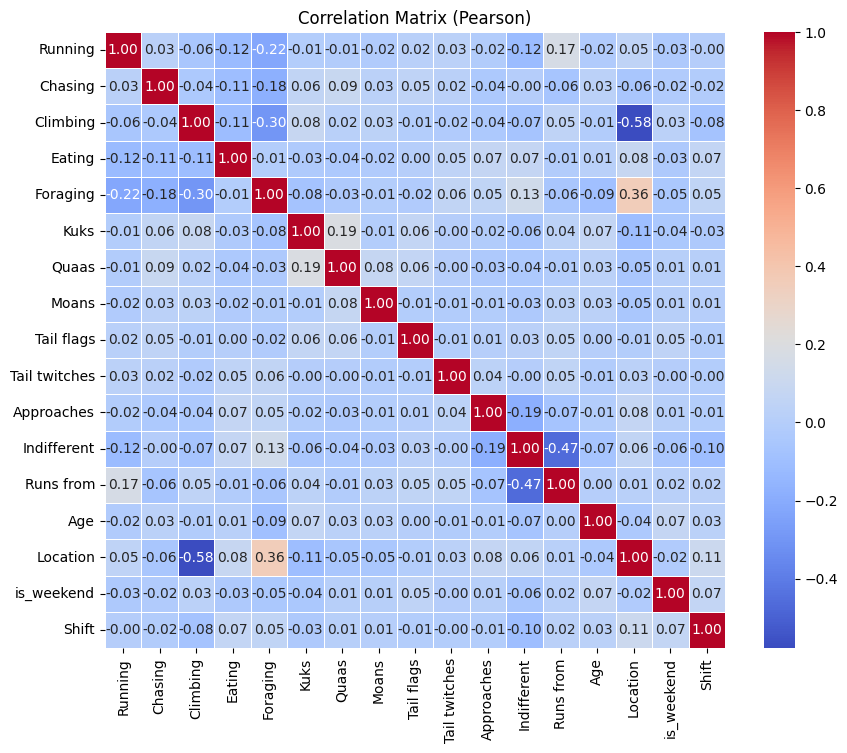

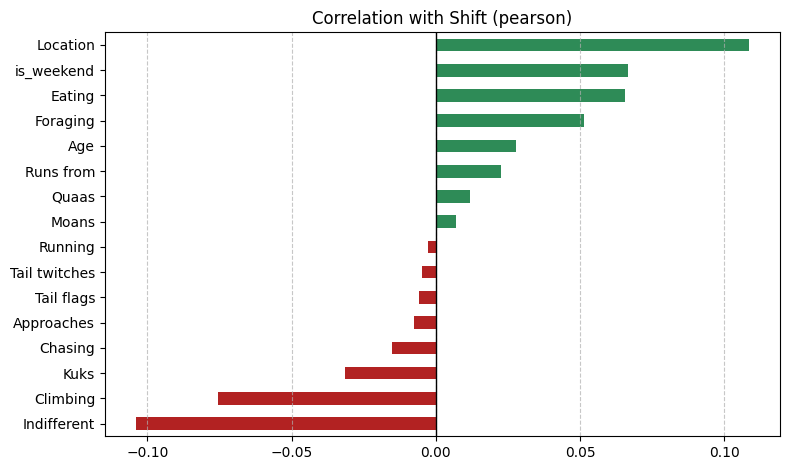

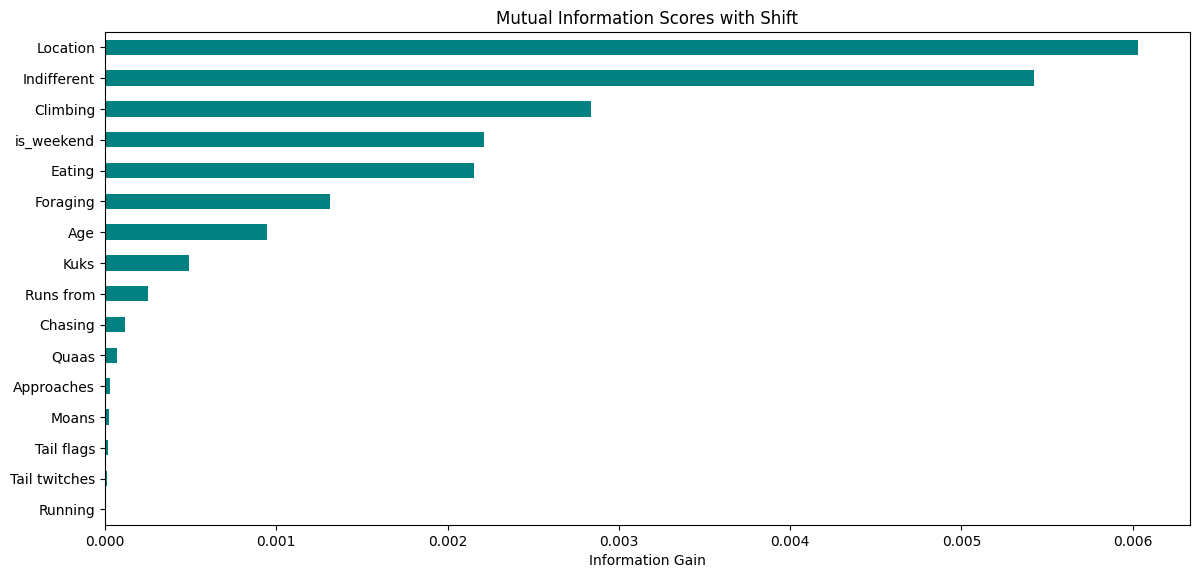

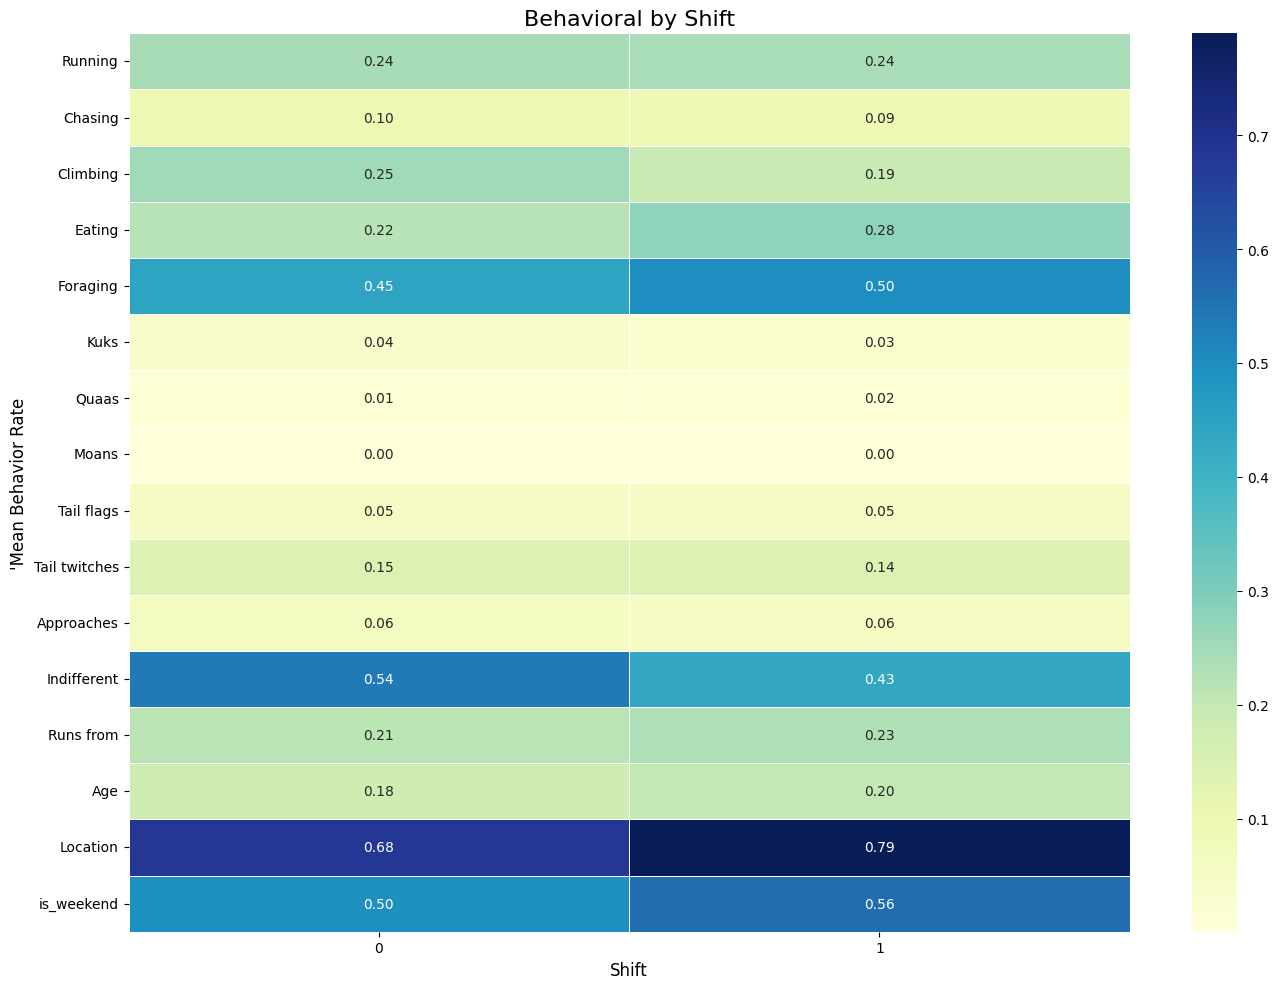

In [616]:
behaviour_cols = [col for col in behaviour_cols if col != TARGET]

plot_correlation(df, behaviour_cols+[TARGET])
plot_target_corr(df, behaviour_cols, TARGET, method="pearson") #linear
plot_mutual_information(df, behaviour_cols, TARGET) #non-linear (entropy)
plot_cluster_behavior_means(df, behaviour_cols, TARGET)
#plot_behavior_stacked_bar(df, behaviour_cols, TARGET)
#plot_behavior_grouped_bar(df, behaviour_cols, TARGET)

#Purpose: understand structure of features and relationship with target

Feature Engineering

In [617]:
def target_encoding(train, test, cols, target_name, folds=5, smoothing=10):
    train_encoded = train.copy()
    test_encoded = test.copy()
    global_mean = train[target_name].mean()

    for col in cols:

        counts = train.groupby(col)[target_name].count()
        means = train.groupby(col)[target_name].mean()
        mapping = (counts * means + smoothing * global_mean) / (counts + smoothing) #shrinkage
        test_encoded[f'{col}_target_enc'] = test_encoded[col].map(mapping).fillna(global_mean)

        train_encoded[f'{col}_target_enc'] = np.nan
        kf = KFold(n_splits=folds, shuffle=True, random_state=42)
        for train_idx, val_idx in kf.split(train): #using oof means, generalises + prevents leakage
            fold_counts = train.iloc[train_idx].groupby(col)[target_name].count()
            fold_means = train.iloc[train_idx].groupby(col)[target_name].mean()
            fold_mapping = (fold_counts * fold_means + smoothing * global_mean) / (fold_counts + smoothing)
            train_encoded.loc[train_encoded.index[val_idx], f'{col}_target_enc'] = \
                train_encoded.loc[train_encoded.index[val_idx], col].map(fold_mapping)
        train_encoded[f'{col}_target_enc'] = train_encoded[f'{col}_target_enc'].fillna(global_mean)
    return train_encoded, test_encoded

def frequency_encoding(train, test, cols):
    train_encoded = train.copy()
    test_encoded = test.copy()
    for col in cols:
        freq_map = train[col].value_counts(normalize=True).to_dict()
        global_fallback = 0 #ultra rare, 1/len(train)?
        train_encoded[f'{col}_freq_enc'] = train_encoded[col].map(freq_map).fillna(global_fallback)
        test_encoded[f'{col}_freq_enc'] = test_encoded[col].map(freq_map).fillna(global_fallback)
    return train_encoded, test_encoded

def create_cluster_fit(train_df, name, train_data, n=10, ADD=True):
    temp_df = train_df.copy()
    cluster_col_name = f'{name}_cluster'
    km = KMeans(n_clusters=n, n_init=10, random_state=42)
    cluster_labels = km.fit_predict(train_data)
    temp_df[cluster_col_name] = cluster_labels
    km.cluster_counts_ = temp_df[cluster_col_name].value_counts().to_dict()

    if ADD:
        dist_matrix = km.transform(train_data)
        temp_df[f'{name}_dist_to_center'] = dist_matrix[np.arange(len(dist_matrix)), cluster_labels]
        dist_cols = [f'{name}_dist_to_c{i}' for i in range(n)]
        dist_df = pd.DataFrame(dist_matrix, columns=dist_cols, index=temp_df.index)
        temp_df = pd.concat([temp_df, dist_df], axis=1)
        temp_df[f'{name}_cluster_density'] = temp_df[cluster_col_name].map(km.cluster_counts_)
    return temp_df, km

def create_cluster_transform(test_df, name, test_data, km, ADD=True):
    temp_df = test_df.copy()
    cluster_col_name = f'{name}_cluster'
    n = km.n_clusters
    cluster_labels = km.predict(test_data)
    temp_df[cluster_col_name] = cluster_labels

    if ADD:
        dist_matrix = km.transform(test_data)
        temp_df[f'{name}_dist_to_center'] = dist_matrix[np.arange(len(dist_matrix)), cluster_labels]
        dist_cols = [f'{name}_dist_to_c{i}' for i in range(n)]
        dist_df = pd.DataFrame(dist_matrix, columns=dist_cols, index=temp_df.index)
        temp_df = pd.concat([temp_df, dist_df], axis=1)
        temp_df[f'{name}_cluster_density'] = temp_df[cluster_col_name].map(km.cluster_counts_)
    return temp_df

def knn_smoothing_fit(train_df, target_col, smooth_cols, input_cols, k=10, n_splits=5):
    temp_df = train_df.copy()
    all_to_smooth = [target_col] + smooth_cols
    for col in all_to_smooth:
        temp_df[f'knn_smooth_{col}'] = np.nan

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    for train_idx, val_idx in kf.split(temp_df):
        df_train_folds = temp_df.iloc[train_idx]
        df_val_fold = temp_df.iloc[val_idx]

        knn_fold = NearestNeighbors(n_neighbors=k)
        knn_fold.fit(df_train_folds[input_cols])
        _, indices = knn_fold.kneighbors(df_val_fold[input_cols]) #OOF KNN target smoothing

        for col in all_to_smooth:
            train_values = df_train_folds[col].values
            smoothed_values = np.mean(train_values[indices], axis=1)
            temp_df.iloc[val_idx, temp_df.columns.get_loc(f'knn_smooth_{col}')] = smoothed_values

    global_knn = NearestNeighbors(n_neighbors=k)
    global_knn.fit(temp_df[input_cols])
    global_knn.train_values_dict_ = {col: temp_df[col].values for col in all_to_smooth} #store original values
    global_knn.k_value_ = k
    global_knn.smooth_cols_ = all_to_smooth
    return temp_df, global_knn

def knn_smoothing_transform(test_df, input_cols, global_knn):
    temp_df = test_df.copy()
    _, indices = global_knn.kneighbors(temp_df[input_cols], n_neighbors=global_knn.k_value_)

    for col in global_knn.smooth_cols_:
        neighbor_values = global_knn.train_values_dict_[col][indices] #uses original as souce of neighbours
        temp_df[f'knn_smooth_{col}'] = np.mean(neighbor_values, axis=1)
    return temp_df

def leaf_embedding_fit(train_df, input_cols, target_col, n_estimators=50, max_depth=4):
    X = train_df[input_cols]
    y = train_df[target_col]

    oof_leaves = np.zeros((len(X), n_estimators))
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    leaf_cols = [f'leaf_tree_{i}' for i in range(n_estimators)]
    for train_idx, val_idx in kf.split(X):
        X_t, X_v = X.iloc[train_idx], X.iloc[val_idx]
        y_t = y.iloc[train_idx]
        fold_model = lgb.LGBMClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42, verbosity=-1)
        fold_model.fit(X_t, y_t)
        oof_leaves[val_idx, :] = fold_model.predict(X_v, pred_leaf=True) #returns leaf index

    global_model = lgb.LGBMClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42, verbosity=-1) #uses all information
    global_model.fit(X, y)
    train_leaf_df = pd.DataFrame(oof_leaves, columns=leaf_cols, index=train_df.index).astype(int)
    return pd.concat([train_df, train_leaf_df], axis=1), global_model

def leaf_embedding_transform(test_df, input_cols, global_model):
    leaf_indices = global_model.predict(test_df[input_cols], pred_leaf=True)
    leaf_cols = [f'leaf_tree_{i}' for i in range(leaf_indices.shape[1])] #1 col per tree
    test_leaf_df = pd.DataFrame(leaf_indices, columns=leaf_cols, index=test_df.index).astype(int)
    return pd.concat([test_df, test_leaf_df], axis=1)

behaviour_cols = [col for col in behaviour_cols if col != TARGET]
train_df["n_behave"] = train_df[behaviour_cols].sum(axis=1)
test_df["n_behave"] = test_df[behaviour_cols].sum(axis=1)
train_df["hectare_interaction"] = train_df["HectareWE"] * train_df["HectareSN"] #interaction
test_df["hectare_interaction"] = test_df["HectareWE"] * train_df["HectareSN"]

scaler = StandardScaler() #faster convergence and same scale for distance-based models
train_df[['X', 'Y']] = scaler.fit_transform(train_df[['X', 'Y']])
test_df[['X', 'Y']] = scaler.transform(test_df[['X', 'Y']])
train_df, km = create_cluster_fit(train_df, "Geo", train_df[coords], n=15) #fitted only on train to prevent leakage
test_df = create_cluster_transform(test_df, "Geo", test_df[coords], km)
#train_df, km = create_cluster_fit(train_df, "Behave", train_df[behaviour_cols], n=15) #optional behavioural clusters
#test_df = create_cluster_transform(test_df, "Behave", test_df[behaviour_cols], km)
train_df, global_knn = knn_smoothing_fit(train_df, TARGET, smooth_cols=behaviour_cols, input_cols=coords, k=20) #target and feature smoothing
test_df = knn_smoothing_transform(test_df, input_cols=coords, global_knn=global_knn)
#train_df, global_model = leaf_embedding_fit(train_df, behaviour_cols, TARGET, n_estimators=20) #optional leaf embeddings (non-linear mapping/coordinates on each tree)
#test_df = leaf_embedding_transform(test_df, behaviour_cols, global_model)

features_to_encode = behaviour_cols+day_cols+["Geo_cluster"]#+["Behave_cluster"]
train_df, test_df = target_encoding(train_df, test_df, features_to_encode, TARGET) #more info, global context
train_df, test_df = frequency_encoding(train_df, test_df, features_to_encode) #parse rarity

#DAE(only keep predictable part), SVD, time-based, PCA orthogonalisation, etc?

#Purpose: raw data into more useful inputs for ml, detect patterns more easily, reduce noise

Data Preprocessing

In [618]:
feature_cols = [col for col in train_df.columns if col != TARGET]
dead_cols = [c for c in feature_cols if np.isfinite(train_df[c]).sum() == 0 or train_df[c].nunique(dropna=False) <= 1] #useless
feature_cols = [c for c in feature_cols if c not in dead_cols]
temp_df = train_df[feature_cols].replace([np.inf, -np.inf], np.nan)
f_max = temp_df.max()
f_min = temp_df.min()
train_df[feature_cols] = train_df[feature_cols].replace(np.inf, f_max).replace(-np.inf, f_min).fillna(temp_df.median())
test_df[feature_cols] = test_df[feature_cols].replace(np.inf, f_max).replace(-np.inf, f_min).fillna(temp_df.median()) #lr can't handle -inf and inf
X_train = train_df[feature_cols]
y_train = train_df[TARGET]
y_test = test_df[TARGET]
#print(f"Features: {feature_cols}")
print(f"Total number of features: {len(feature_cols)}")
print(f"Final NaN check: {train_df[feature_cols].isna().sum().sum()}")
#plot_target_corr(train_df, feature_cols, TARGET, method="kendall") #non-linear

#Purpose: turn into format compatible with models

Total number of features: 460
Final NaN check: 0


Hyperparams

In [619]:
lr_params = {
    "C": 1,
    "max_iter": 10000, #wow
    "solver": "lbfgs",
    "penalty": "l2",
}
rf_params = {
    "n_estimators": 100,
    "n_jobs": -1,
    #"max_depth": None,
    #"min_samples_split": 2, #higher means more regularisation
    #"min_samples_leaf": 1 #important to tune
}

xgb_params = {
    "n_estimators": 100,
    "max_depth": 6,
    "learning_rate": 0.1,
    #"eval_metric": "auc" #could add early stopping, requires val set
}

#can be tuned, may require to split further to train, val, test sets
#can have different model types on different subset of data, also NN, LightGBM, CatBoost, etc

#Purpose: hyper-params

Feature Selection


Logistic Regression LE (Pass 1)


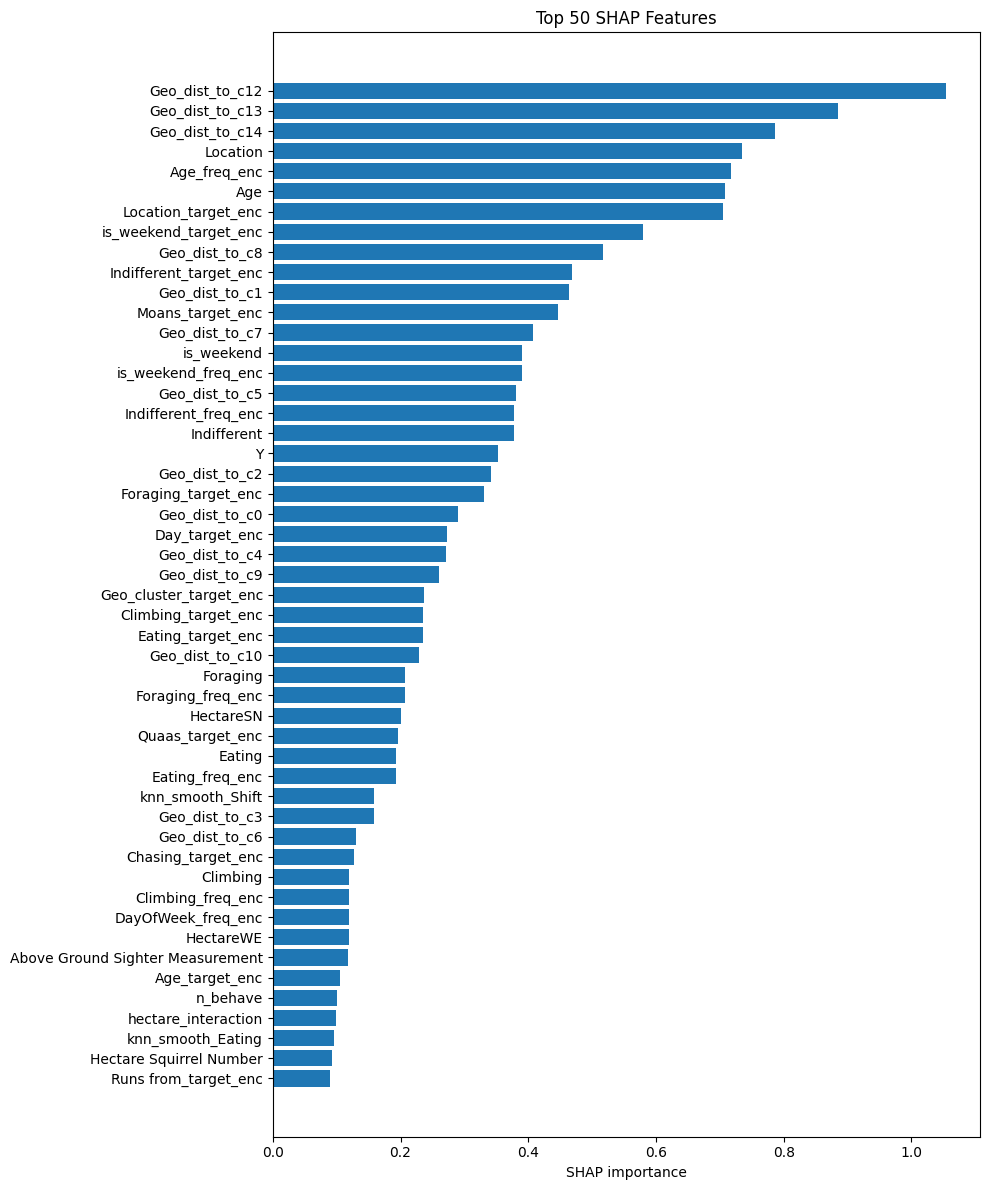


Logistic Regression OHE (Pass 1)


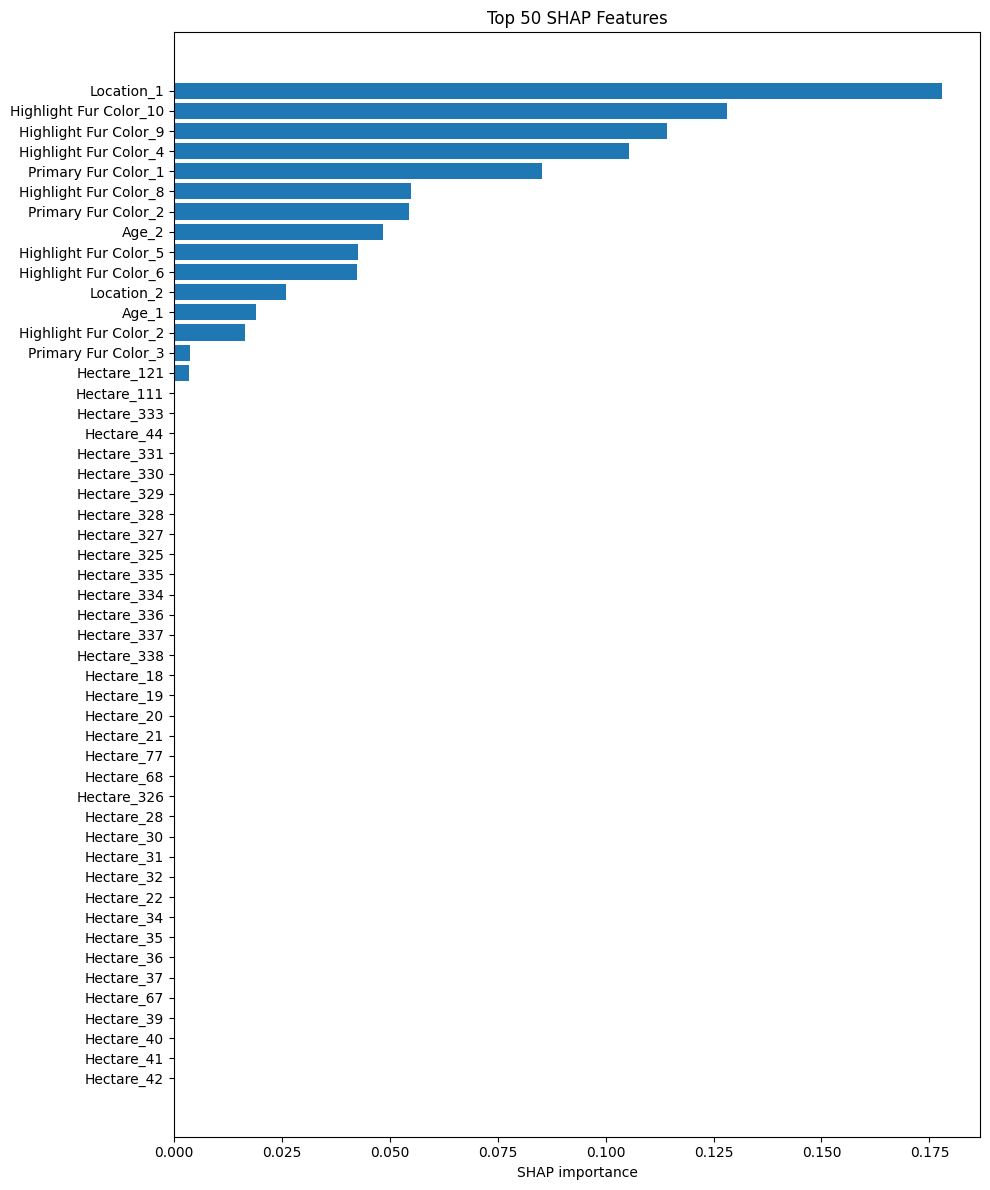


Random Forest (Pass 1)


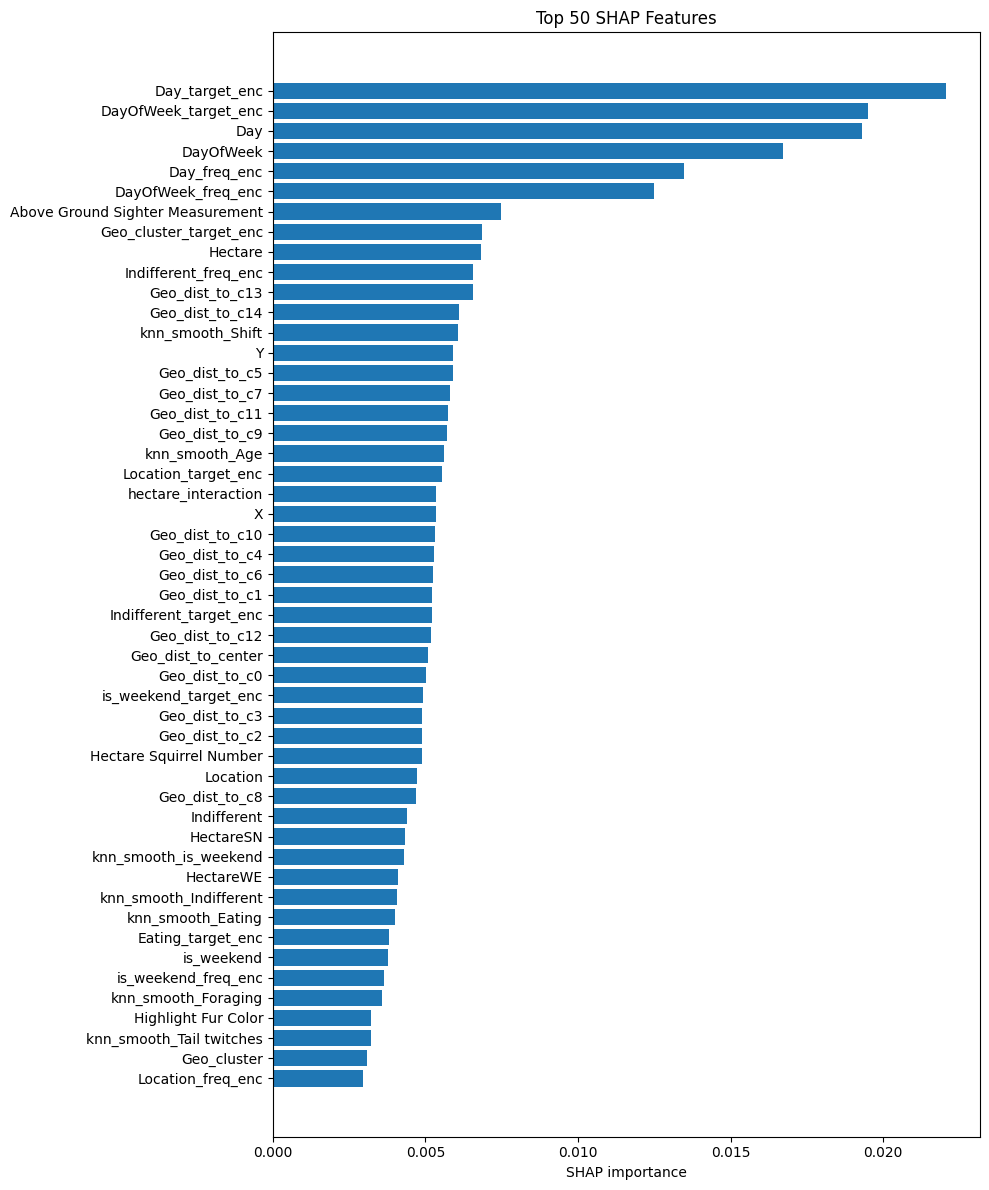


XGBoost (Pass 1)


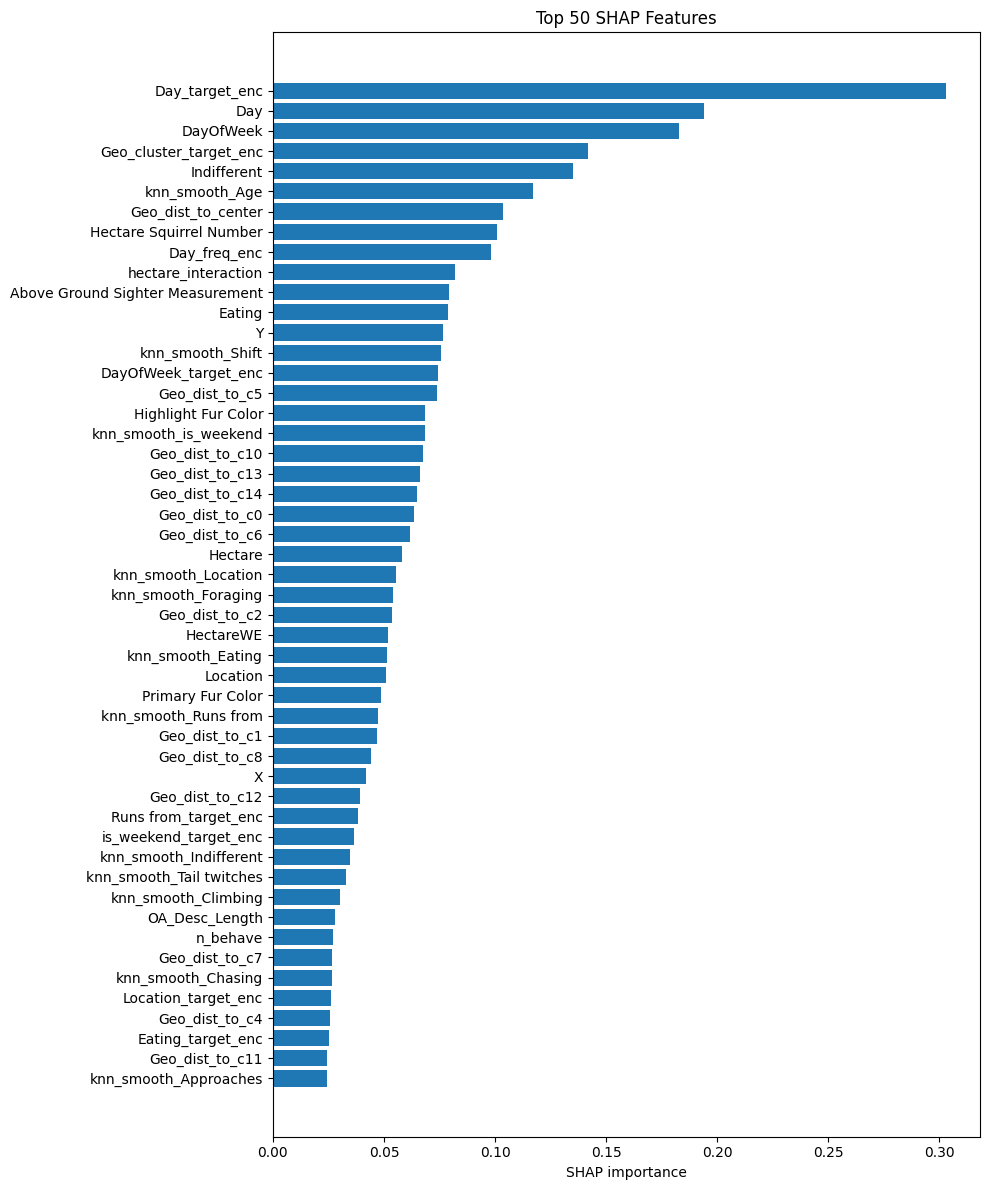

In [620]:
def run_lr_kfold_cv_importance(train_df, test_df, feature_cols, target, params, n_splits=5, alpha=0.01):
    X = train_df[feature_cols]
    y = train_df[target]
    X_test = test_df[feature_cols]

    #ideally should use one-hot encoded instead of label-encoded
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof_preds = np.zeros(len(train_df))
    test_preds = np.zeros(len(test_df))

    shap_importances = []
    perm_importances = []
    models = []
    for train_idx, val_idx in skf.split(X, y):
        X_train, y_train = X.iloc[train_idx].copy(), y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx].copy(), y.iloc[val_idx]
        X_test_fold = X_test.copy()

        #LR requires more preprocessing as more sensitive to scale and outliers (done within fold)
        num_cols = X_train.select_dtypes(include=[np.number]).columns
        lower = X_train[num_cols].quantile(alpha)
        upper = X_train[num_cols].quantile(1 - alpha)
        X_train[num_cols] = X_train[num_cols].clip(lower=lower, upper=upper, axis=1)
        X_val[num_cols] = X_val[num_cols].clip(lower=lower, upper=upper, axis=1)
        X_test_fold[num_cols] = X_test_fold[num_cols].clip(lower=lower, upper=upper, axis=1)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        X_test_scaled = scaler.transform(X_test_fold)
        y_val = np.asarray(y_val)

        model = LogisticRegression(**{**params, "random_state": 42})
        model.fit(X_train_scaled, y_train)
        models.append(model)

        oof_preds[val_idx] = model.predict_proba(X_val_scaled)[:, 1] #OOF pred
        test_preds += model.predict_proba(X_test_scaled)[:, 1] / n_splits #test_pred

        explainer = shap.LinearExplainer(model, X_train_scaled) #shap values
        idx = np.random.choice(X_val.shape[0], size=min(300, X_val.shape[0]), replace=False)
        #X_val_scaled = X_val_scaled[idx]
        #y_val = y_val[idx]
        shap_values = explainer(X_val_scaled)
        vals = shap_values.values if hasattr(shap_values, "values") else shap_values
        shap_importances.append(np.abs(vals).mean(axis=0))

    shap_importance = np.mean(shap_importances, axis=0)
    shap_df = pd.DataFrame({
        "feature": feature_cols,
        "shap_importance": shap_importance
    }).sort_values("shap_importance", ascending=False)
    return models, oof_preds, test_preds, shap_df

def run_rf_kfold_cv_importance(train_df, test_df, feature_cols, target, params, n_splits=5): #same as above, probably could be abstrated away
    X = train_df[feature_cols]
    y = train_df[target]
    X_test = test_df[feature_cols]

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof_preds = np.zeros(len(train_df))
    test_preds = np.zeros(len(test_df))

    shap_importances = []
    perm_importances = []
    models = []
    for train_idx, val_idx in skf.split(X, y):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

        model = RandomForestClassifier(**{**params, "random_state": 42})
        model.fit(X_train, y_train)
        models.append(model)

        oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
        test_preds += model.predict_proba(X_test)[:, 1] / n_splits

        explainer = shap.TreeExplainer(model)
        #X_val = X_val.sample(min(300, len(X_val)), random_state=42)
        #y_val = y_val.loc[X_val.index]
        shap_values = explainer(X_val)
        vals = shap_values.values if hasattr(shap_values, "values") else shap_values
        if len(vals.shape) == 3:
            vals = vals[:, :, 1]
        shap_importances.append(np.abs(vals).mean(axis=0))

    shap_importance = np.mean(shap_importances, axis=0)
    shap_df = pd.DataFrame({
        "feature": feature_cols,
        "shap_importance": shap_importance
    }).sort_values("shap_importance", ascending=False)
    return models, oof_preds, test_preds, shap_df

def run_xgb_kfold_cv_importance(train_df, test_df, feature_cols, target, params, n_splits=5):
    X = train_df[feature_cols]
    y = train_df[target]
    X_test = test_df[feature_cols]

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof_preds = np.zeros(len(train_df))
    test_preds = np.zeros(len(test_df))

    shap_importances = []
    perm_importances = []
    models = []
    for train_idx, val_idx in skf.split(X, y):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

        model = xgb.XGBClassifier(**{**params, "random_state": 42})
        model.fit(X_train, y_train)
        models.append(model)

        oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
        test_preds += model.predict_proba(X_test)[:, 1] / n_splits

        explainer = shap.TreeExplainer(model)
        #X_val = X_val.sample(min(300, len(X_val)), random_state=42)
        #y_val = y_val.loc[X_val.index]
        shap_values = explainer(X_val)
        vals = shap_values.values if hasattr(shap_values, "values") else shap_values
        if len(vals.shape) == 3:
            vals = vals[:, :, 1]
        shap_importances.append(np.abs(vals).mean(axis=0))

    shap_importance = np.mean(shap_importances, axis=0)
    shap_df = pd.DataFrame({
        "feature": feature_cols,
        "shap_importance": shap_importance
    }).sort_values("shap_importance", ascending=False)
    return models, oof_preds, test_preds, shap_df

def top_k_features(shap_df, top_k=50):
    top_df = shap_df.sort_values("shap_importance", ascending=False).head(top_k)

    plt.figure(figsize=(10, 12))
    plt.barh(top_df["feature"][::-1], top_df["shap_importance"][::-1])
    plt.xlabel("SHAP importance")
    plt.title(f"Top {top_k} SHAP Features")
    plt.tight_layout()
    plt.show()
    return top_df["feature"].tolist()
#basically using OOF for train (robust) and global OOS for test (uses all data)


#Averaged across folds to ensure stability across folds, reduces variance, luck (one fold), etc
#SHAP (true marginal contribution of each feature to the baseline prediction)
#more detailed (local+global) though not used here, captures interaction effects, non-linear relationships, but very slow and splits importance across correlated features (duplicates)

#Permutation (drop in performance from drop of feature)
#based on model performance, easier to interpret, doesn't do well with feature correlation, also slow
#despite getting 97%, decided to remove as too slow and am impatient

le_cols = [c for c in feature_cols if c not in ohe_cols]
ohe_cols = [c for c in feature_cols if c not in le_cols]
#Same arguments as above, LE: assign order but less dimensions so faster, ""

print("\nLogistic Regression LE (Pass 1)")
lr1_model, lr1_oof, lr1_test, lr1_shap_df = run_lr_kfold_cv_importance(train_df, test_df, le_cols, TARGET, lr_params, n_splits=5)
lr1_cols = top_k_features(lr1_shap_df, top_k=50)

print("\nLogistic Regression OHE (Pass 1)")
lr2_model, lr2_oof, lr2_test, lr2_shap_df = run_lr_kfold_cv_importance(train_df, test_df, ohe_cols, TARGET, lr_params, n_splits=5)
lr2_cols = top_k_features(lr2_shap_df, top_k=50)

print("\nRandom Forest (Pass 1)")
rf_model, rf_oof, rf_test, rf_shap_df = run_rf_kfold_cv_importance(train_df, test_df, le_cols, TARGET, rf_params, n_splits=5)
rf_cols = top_k_features(rf_shap_df, top_k=50)

print("\nXGBoost (Pass 1)")
xgb_model, xgb_oof, xgb_test, xgb_shap_df = run_xgb_kfold_cv_importance(train_df, test_df, le_cols, TARGET, xgb_params, n_splits=5)
xgb_cols = top_k_features(xgb_shap_df, top_k=50)

#slow, so could do sampling X_val, model native SHAP, etc
#alternatively could do something like top k stability, permutation importance,
#also hyperparam tuning w/ val set (most are currently arbitrarily chosen), tune threshold, recursive pruning

#Purpose: parsimonious parameterisation, simplifying model, reduces overfitting, converges faster, reduces redudancy, hopefully improves performance
#Selected top 50 features based on ranks of mean abs SHAP across folds, could do freq based

#LR: poorer performance with ohe vs le for some reason, why?, idk
#DT: time-based features have high impact on predictions, either sign of leakage or hidden temporal pattern, also not present in LR (non-linear pattern?)
#may require walk forward validation to ensure stability across time

Base Models

In [621]:
#DT has can handle complex non-linear patterns, requires less strict assumptions and preprocessing (no scaling required), etc
#StratifiedKFold as maintains class dist, less unstable, less dependent on random split and produces oof for stacking (1 model per fold)
#prefered over bootstrapping as full coverage (efficient), less biased/noisy dist, lower risk of leakage, etc

print("\nLogistic Regression LE (Pass 2)")
print(f"Number of features: {len(lr1_cols)}")
#print(f"Features {lr1_cols}")
lr1_model, lr1_oof_preds, lr1_test_preds = run_lr_kfold(train_df, test_df, lr1_cols, TARGET, lr_params, n_splits=5)
lr1_oof_labels = (lr1_oof_preds > 0.5).astype(int)
print(f"Accuracy: {accuracy_score(y_train, lr1_oof_labels)*100:.2f}%")
print(f"ROC_AUC: {roc_auc_score(y_train, lr1_oof_preds)*100:.2f}%")

print("\nLogistic Regression OHE (Pass 2)")
print(f"Number of features: {len(lr2_cols)}")
#print(f"Features {lr2_cols}")
lr2_model, lr2_oof_preds, lr2_test_preds = run_lr_kfold(train_df, test_df, lr2_cols, TARGET, lr_params, n_splits=5)
lr2_oof_labels = (lr2_oof_preds > 0.5).astype(int)
print(f"Accuracy: {accuracy_score(y_train, lr2_oof_labels)*100:.2f}%")
print(f"ROC_AUC: {roc_auc_score(y_train, lr2_oof_preds)*100:.2f}%")

#bagging, reduce variance (less overfit+stable), but high bias (underfit)
print("\nRandom Forest (Pass 2)")
print(f"Number of features: {len(rf_cols)}")
#print(f"Features {rf_cols}")
rf_model, rf_oof_preds, rf_test_preds = run_rf_kfold(train_df, test_df, rf_cols, TARGET, rf_params, n_splits=5)
rf_oof_labels = (rf_oof_preds > 0.5).astype(int) #label is threshold dependent
print(f"Accuracy: {accuracy_score(y_train, rf_oof_labels)*100:.2f}%") #bad on imbalanced data (favour majority class)
print(f"ROC_AUC: {roc_auc_score(y_train, rf_oof_preds)*100:.2f}%") #uses prob directly, whereas f1 requires threshold -> ard 0/1 (ignors prob),

#boosting, reduce bias (higher accuracy), but risk of overfit and requires tuning
print("\nXGBoost (Pass 2)")
print(f"Number of features: {len(xgb_cols)}")
#print(f"Features {xgb_cols}")
xgb_model, xgb_oof_preds, xgb_test_preds = run_xgb_kfold(train_df, test_df, xgb_cols, TARGET, xgb_params, n_splits=5)
xgb_oof_labels = (xgb_oof_preds > 0.5).astype(int)
print(f"Accuracy: {accuracy_score(y_train, xgb_oof_labels)*100:.2f}%")
print(f"ROC_AUC: {roc_auc_score(y_train, xgb_oof_preds)*100:.2f}%")

#could do feat. eng. specific to LR to capture non-linear patterns (polynomial, transformations, interactions)

#Purpose: Different models with different set of featurs may capture differnt patetrns in data, averages out errors (diversification), generalises better


Logistic Regression LE (Pass 2)
Number of features: 50
Accuracy: 61.66%
ROC_AUC: 64.72%

Logistic Regression OHE (Pass 2)
Number of features: 50
Accuracy: 57.49%
ROC_AUC: 56.50%

Random Forest (Pass 2)
Number of features: 50
Accuracy: 87.80%
ROC_AUC: 95.41%

XGBoost (Pass 2)
Number of features: 50
Accuracy: 81.60%
ROC_AUC: 89.43%


Final Evaluation

In [622]:
#Majority voting, higher bias, simpler
print("\nMajority Voting")
final_preds = (lr1_test_preds + lr2_test_preds + rf_test_preds + xgb_test_preds) / 4
final_labels = (final_preds > 0.5).astype(int)
print(f"Accuracy: {accuracy_score(y_test, final_labels)*100:.2f}%")
print(f"ROC_AUC: {roc_auc_score(y_test, final_preds)*100:.2f}%")

#Stacking, higher variance, interpretable
print("\nStacking")
X_meta = np.column_stack([lr1_oof_preds, lr2_oof_preds, rf_oof_preds, xgb_oof_preds])
X_test_meta = np.column_stack([lr1_test_preds, lr2_test_preds, rf_test_preds, xgb_test_preds])

scaler = StandardScaler() #just good practice
X_meta_scaled = scaler.fit_transform(X_meta)
X_test_meta_scaled = scaler.transform(X_test_meta)

X_meta_sm = sm.add_constant(X_meta_scaled)
logit_model = sm.Logit(y_train, X_meta_sm) #combine model preds to make up for their disadv, learn weighting
result = logit_model.fit_regularized(alpha=1, L1_wt=0, disp=0) #Ridge (L2) + learns relationship between oof model preds and y
print(result.summary())
final_preds = result.predict(sm.add_constant(X_test_meta_scaled)) #final output (agg from all models)
final_labels = (final_preds > 0.5).astype(int)
"""
meta_model = LogisticRegression(penalty="l2", C=0.5, solver="lbfgs")
meta_model.fit(X_meta_scaled, y_train)
final_preds = meta_model.predict_proba(X_test_meta_scaled)[:, 1]
"""
final_labels = (final_preds > 0.5).astype(int)
print(f"Accuracy: {accuracy_score(y_test, final_labels)*100:.2f}%")
print(f"ROC_AUC: {roc_auc_score(y_test, final_preds)*100:.2f}%") #this is w/o hyperparameter tuning and calibration, etc
#could use other DT instead of LR, with same arguments as for base model, but just decided on LR as intepretable and safer, DT is probably overkill for this

#beta for base model loadings, z-stat shows statistical significance from H0 (B=0), Pseudo R^2 of 61%, const of 0.425 (log-odds), so biased towards class 1 (>0), blah blah
#performance mostly from rf: x2 = 3.43

#currently top K, n_folds, alll hyperparams are arbitrarily chosen

#Purpose: combined to final prediction


Majority Voting
Accuracy: 85.95%
ROC_AUC: 93.71%

Stacking
                           Logit Regression Results                           
Dep. Variable:                  Shift   No. Observations:                 2418
Model:                          Logit   Df Residuals:                     2413
Method:                           MLE   Df Model:                            4
Date:                Tue, 12 May 2026   Pseudo R-squ.:                  0.6104
Time:                        12:38:30   Log-Likelihood:                -646.98
converged:                       True   LL-Null:                       -1660.5
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4250      0.073      5.849      0.000       0.283       0.567
x1            -0.2823      0.083     -3.410      0.001      -0.445     

Quick Temporal Investigation

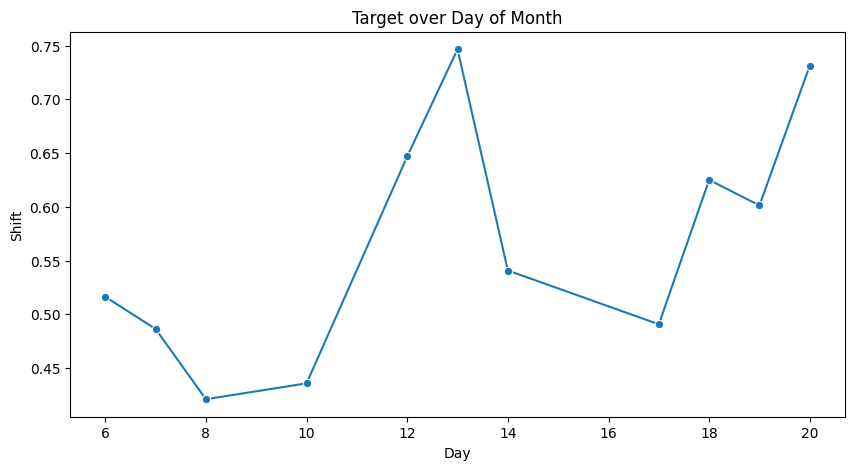

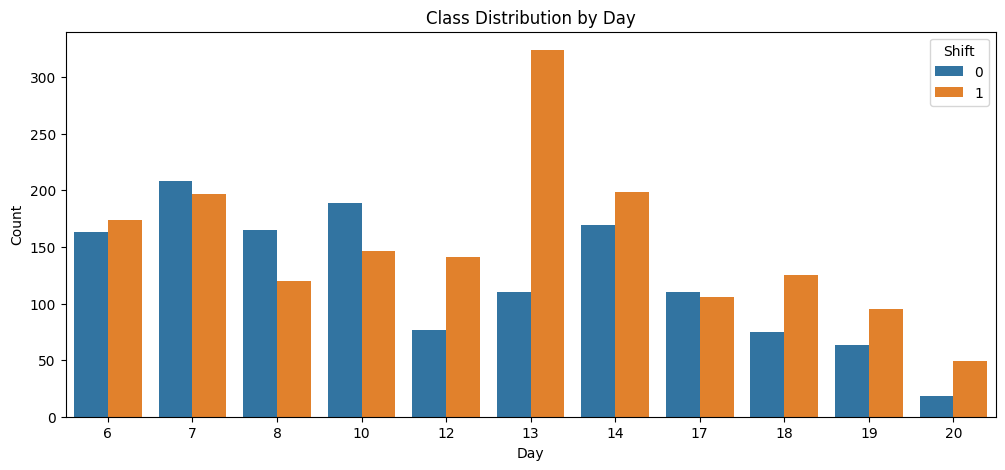

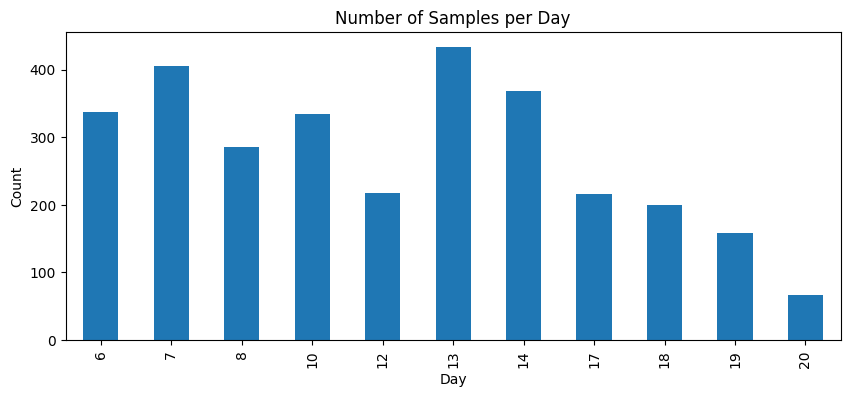

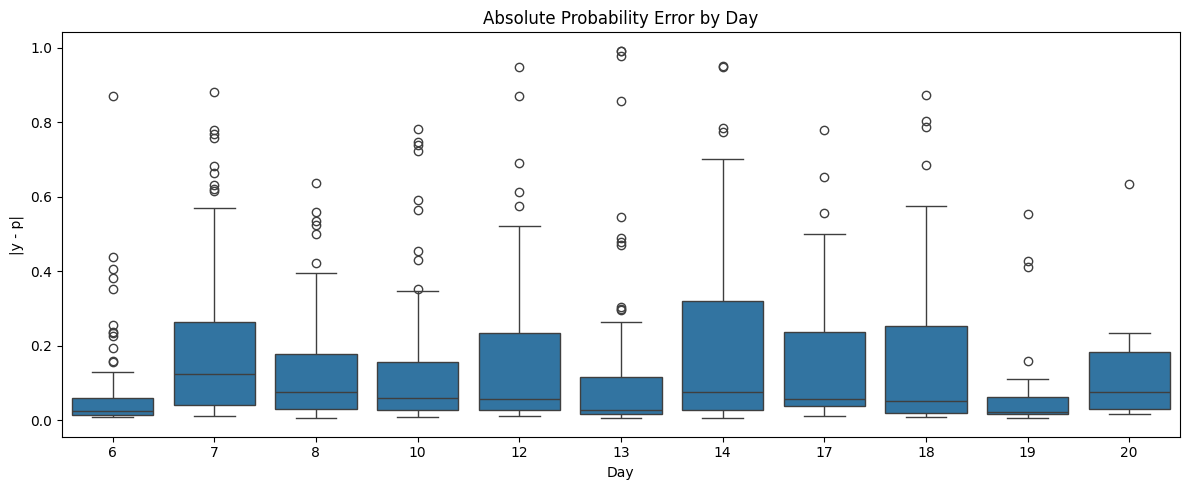

In [623]:
def plot_target_over_day(df, target_col):
    daily = df.groupby("Day")[target_col].mean().reset_index()

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=daily, x="Day", y=target_col, marker="o")
    plt.title("Target over Day of Month")
    plt.xlabel("Day")
    plt.ylabel(target_col)
    plt.show()

def plot_class_counts_by_day(df, target_col):
    plt.figure(figsize=(12, 5))
    sns.countplot(data=df, x="Day", hue=target_col)
    plt.title("Class Distribution by Day")
    plt.xlabel("Day")
    plt.ylabel("Count")
    plt.show()

def plot_samples_per_day(df):
    counts = df["Day"].value_counts().sort_index()

    plt.figure(figsize=(10, 4))
    counts.plot(kind="bar")
    plt.title("Number of Samples per Day")
    plt.xlabel("Day")
    plt.ylabel("Count")
    plt.show()

def plot_probability_errors_by_day(df, y_true, y_pred_proba, use_absolute=True):
    temp = df.copy()

    residuals = y_true - y_pred_proba
    temp["error"] = np.abs(residuals) if use_absolute else residuals

    plt.figure(figsize=(12, 5))
    sns.boxplot(data=temp, x="Day", y="error")

    ylabel = "|y - p|" if use_absolute else "y - p"
    title = "Absolute Probability Error by Day" if use_absolute else "Signed Probability Error by Day"

    plt.title(title)
    plt.xlabel("Day")
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

plot_target_over_day(df, TARGET)
print("")
plot_class_counts_by_day(df, TARGET)
print("")
plot_samples_per_day(df)
#plot_probability_errors_by_day(df, final_preds, y_test)
#could further investigate, cuz only 1 month of data so might not be stable
#data augmentation(shuffling) to prevent pure memorisation, might be issue K-fold not taking into account time

In [624]:
def remove_day_features(cols):
    return [col for col in cols if "Day" not in col]

lr1_cols = remove_day_features(lr1_cols)
lr2_cols = remove_day_features(lr2_cols)
rf_cols  = remove_day_features(rf_cols)
xgb_cols = remove_day_features(xgb_cols)

print("\nLogistic Regression LE (Pass 2)")
print(f"Number of features: {len(lr1_cols)}")
lr1_model, lr1_oof_preds, lr1_test_preds = run_lr_kfold(train_df, test_df, lr1_cols, TARGET, lr_params, n_splits=5)
lr1_oof_labels = (lr1_oof_preds > 0.5).astype(int)
print(f"Accuracy: {accuracy_score(y_train, lr1_oof_labels)*100:.2f}%")
print(f"ROC_AUC: {roc_auc_score(y_train, lr1_oof_preds)*100:.2f}%")

print("\nLogistic Regression OHE (Pass 2)")
print(f"Number of features: {len(lr2_cols)}")
lr2_model, lr2_oof_preds, lr2_test_preds = run_lr_kfold(train_df, test_df, lr2_cols, TARGET, lr_params, n_splits=5)
lr2_oof_labels = (lr2_oof_preds > 0.5).astype(int)
print(f"Accuracy: {accuracy_score(y_train, lr2_oof_labels)*100:.2f}%")
print(f"ROC_AUC: {roc_auc_score(y_train, lr2_oof_preds)*100:.2f}%")

print("\nRandom Forest (Pass 2)")
print(f"Number of features: {len(rf_cols)}")
rf_model, rf_oof_preds, rf_test_preds = run_rf_kfold(train_df, test_df, rf_cols, TARGET, rf_params, n_splits=5)
rf_oof_labels = (rf_oof_preds > 0.5).astype(int)
print(f"Accuracy: {accuracy_score(y_train, rf_oof_labels)*100:.2f}%")
print(f"ROC_AUC: {roc_auc_score(y_train, rf_oof_preds)*100:.2f}%")

print("\nXGBoost (Pass 2)")
print(f"Number of features: {len(xgb_cols)}")
xgb_model, xgb_oof_preds, xgb_test_preds = run_xgb_kfold(train_df, test_df, xgb_cols, TARGET, xgb_params, n_splits=5)
xgb_oof_labels = (xgb_oof_preds > 0.5).astype(int)
print(f"Accuracy: {accuracy_score(y_train, xgb_oof_labels)*100:.2f}%")
print(f"ROC_AUC: {roc_auc_score(y_train, xgb_oof_preds)*100:.2f}%")


print("\nMajority Voting")
final_preds = (lr1_test_preds + lr2_test_preds + rf_test_preds + xgb_test_preds) / 4
final_labels = (final_preds > 0.5).astype(int)
print(f"Accuracy: {accuracy_score(y_test, final_labels)*100:.2f}%")
print(f"ROC_AUC: {roc_auc_score(y_test, final_preds)*100:.2f}%")

print("\nStacking")
X_meta = np.column_stack([lr1_oof_preds, lr2_oof_preds, rf_oof_preds, xgb_oof_preds])
X_test_meta = np.column_stack([lr1_test_preds, lr2_test_preds, rf_test_preds, xgb_test_preds])

scaler = StandardScaler()
X_meta_scaled = scaler.fit_transform(X_meta)
X_test_meta_scaled = scaler.transform(X_test_meta)

X_meta_sm = sm.add_constant(X_meta_scaled)
logit_model = sm.Logit(y_train, X_meta_sm)
result = logit_model.fit_regularized(alpha=1, L1_wt=0, disp=0)
print(result.summary())

final_preds = result.predict(sm.add_constant(X_test_meta_scaled))
final_labels = (final_preds > 0.5).astype(int)

final_labels = (final_preds > 0.5).astype(int)
print(f"Accuracy: {accuracy_score(y_test, final_labels)*100:.2f}%")
print(f"ROC_AUC: {roc_auc_score(y_test, final_preds)*100:.2f}%")

#DT has hard coded splits, so risk shifts in feature distribution
#degredation in bagging is smoother as in parallel (averages out) compared to boosting
#logistic regression degrades even more gracefully as extrapolates
#meta-models may average out drift but also are themselves fragile and exposed to meta-drift

#Key takeaway:time-related features carry information, but whether it is stable is yet to be tested
#requires walk-forward validation and more data

#Purpose: Investigate temporal features


Logistic Regression LE (Pass 2)
Number of features: 48
Accuracy: 60.71%
ROC_AUC: 61.96%

Logistic Regression OHE (Pass 2)
Number of features: 50
Accuracy: 57.49%
ROC_AUC: 56.50%

Random Forest (Pass 2)
Number of features: 44
Accuracy: 75.06%
ROC_AUC: 81.75%

XGBoost (Pass 2)
Number of features: 45
Accuracy: 71.96%
ROC_AUC: 78.07%

Majority Voting
Accuracy: 70.74%
ROC_AUC: 81.74%

Stacking
                           Logit Regression Results                           
Dep. Variable:                  Shift   No. Observations:                 2418
Model:                          Logit   Df Residuals:                     2413
Method:                           MLE   Df Model:                            4
Date:                Tue, 12 May 2026   Pseudo R-squ.:                  0.2513
Time:                        12:38:41   Log-Likelihood:                -1243.2
converged:                       True   LL-Null:                       -1660.5
Covariance Type:            nonrobust   LLR p-value:  